# WISE pyvo Tables to query
* allsky_4band_p3as_cdd
* allwise_p3as_mep (or maybe _psd)?
* neowiser_p1bs_psd

In [57]:
# SEE https://irsa.ipac.caltech.edu/docs/program_interface/sia_allwise_atlas.html

import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.utils.data import download_file
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
from astropy.table import vstack, hstack

import pyvo

In [58]:
meta = pd.read_csv('../ecle-meta-data.csv')

meta

,name,ra,ra_unit,dec,dec_unit,coord_ref,redshift,redshift_ref,classification,classification_ref,radio_data,radio_data_comment,otter,otter_comments
0,2019qiz,04:46:37.880,hour,-10:13:34.90,degree,2019TNSTR1857....1F,0.015100,2019TNSTR1857....1F,TDE,2019TNSCR1921....1S,True,"Kate (very good radio dataset, still need to a...",True,good uvoir dataset
1,SDSS_J0748,07:48:20.6668,hour,+47:12:14.2648,degree,2024arXiv240216951C,0.061600,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available
2,SDSS_J0807,08:07:27.3157,hour,+14:05:37.0892,degree,2024arXiv240216951C,0.073800,2024arXiv240216951C,AGN,2024arXiv240216951C,True,VLASS,False,NaN
3,SDSS_J0938,09:38:01.6376,hour,+13:53:17.0423,degree,2024arXiv240216951C,0.101000,2024arXiv240216951C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN
4,SDSS_J0952,09:52:09.5629,hour,+21:43:13.2979,degree,2024arXiv240216951C,0.079500,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available
5,SDSS_J1055,10:55:26.4177,hour,+56:37:13.1010,degree,2024arXiv240216951C,0.074000,2024arXiv240216951C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN
6,SDSS_J1207,12:07:19.8102,hour,+24:11:55.8789,degree,2024arXiv240216951C,0.050300,2024arXiv240216951C,AGN,2024arXiv240216951C,True,VLASS,False,NaN
7,SDSS_J1241,12:41:34.2561,hour,+44:26:39.2636,degree,2024arXiv240216951C,0.041900,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS, 4 other observations from other p...",False,NaN
8,SDSS_J1247,12:47:26.3719,hour,+07:05:25.0809,degree,2024arXiv240216951C,0.104000,2024arXiv240216951C,AGN,2024arXiv240216951C,True,VLASS,False,NaN
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024arXiv240216951C,0.036500,2024arXiv240216951C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,minimal uvoir


In [81]:
service = pyvo.dal.TAPService('https://irsa.ipac.caltech.edu/TAP')

allwise_table = 'allwise_p3as_psd' # 'allwise_p3as_mep' #
neowise_table = 'neowiser_p1bs_psd'
search_radius_arcseconds = 5 # in arcseconds
search_radius_degree = search_radius_arcseconds / 3600

tabs = []

for ii, row in meta.iterrows():
    print()
    print('################################################')
    print()
    print(row['name'])
    
    coord = SkyCoord(row.ra, row.dec, unit=('hour', 'deg'))
    ra, dec = coord.ra.value, coord.dec.value
    
    query_aw = f'''
    SELECT *
    FROM {allwise_table}
    WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',{ra},{dec},{search_radius_degree}))=1
    '''
    res_aw = service.run_sync(query_aw)
    tab_aw = res.to_table()
    tab_aw['internal_name'] = [row['name']]*len(tab_aw)
    
    query_nw = f'''
    SELECT * 
    FROM {neowise_table}
    WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',{ra},{dec},{search_radius_degree}))=1
    '''
    res_nw = service.run_sync(query_nw)
    tab_nw = res_nw.to_table()
    
    # rename some columns to make vstacking cleaner
    for i in range(1,5):
        tab_nw[f'w{i}mpro'] = tab_nw[f'w{i}mpro_ep']
        # tab_nw[f'w{i}snr'] = tab_nw[f'w{i}mpro_ep']
        tab_nw[f'w{i}sigmpro'] = tab_nw[f'w{i}sigmpro_ep']
        
    
    tab = vstack([tab_nw, tab_aw]) #, table_names=['neowise', 'allwise'], join_type='outer')
    
    print(tab.columns)
    print(tab)
    if len(tab) == 0: continue # don't append this one
    tabs.append(tab)
    
    break


################################################

2019qiz


KeyError: 'w1mpro_ep'

In [84]:
tab_nw

ra,dec,sigra,sigdec,sigradec,glon,glat,elon,elat,w1x,w1y,w2x,w2y,cntr,source_id,frame_num,scan_id,src,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,rchi2,nb,na,w1sat,w2sat,satnum,cc_flags,det_bit,ph_qual,sso_flg,qual_frame,qi_fact,saa_sep,moon_masked,w1frtr,w2frtr,mjd,w1cc_map,w1cc_map_str,w2cc_map,w2cc_map_str,w1sky,w1sigsk,w1conf,w2sky,w2sigsk,w2conf,w1flux,w1sigflux,w2flux,w2sigflux,w1fitr,w2fitr,w1mag,w1sigm,w1flg,w1mcor,w2mag,w2sigm,w2flg,w2mcor,w1mag_1,w1sigm_1,w1flg_1,w2mag_1,w2sigm_1,w2flg_1,w1mag_2,w1sigm_2,w1flg_2,w2mag_2,w2sigm_2,w2flg_2,w1mag_3,w1sigm_3,w1flg_3,w2mag_3,w2sigm_3,w2flg_3,w1mag_4,w1sigm_4,w1flg_4,w2mag_4,w2sigm_4,w2flg_4,w1mag_5,w1sigm_5,w1flg_5,w2mag_5,w2sigm_5,w2flg_5,w1mag_6,w1sigm_6,w1flg_6,w2mag_6,w2sigm_6,w2flg_6,w1mag_7,w1sigm_7,w1flg_7,w2mag_7,w2sigm_7,w2flg_7,w1mag_8,w1sigm_8,w1flg_8,w2mag_8,w2sigm_8,w2flg_8,allwise_cntr,r_allwise,pa_allwise,n_allwise,w1mpro_allwise,w1sigmpro_allwise,w2mpro_allwise,w2sigmpro_allwise,w3mpro_allwise,w3sigmpro_allwise,w4mpro_allwise,w4sigmpro_allwise,tmass_key,r_2mass,pa_2mass,n_2mass,xscprox,j_m_2mass,j_msig_2mass,h_m_2mass,h_msig_2mass,k_m_2mass,k_msig_2mass,x,y,z,spt_ind,htm20
deg,deg,arcsec,arcsec,arcsec,deg,deg,deg,deg,pix,pix,pix,pix,,,,,,mag,mag,,,mag,mag,,,,,,,,,,,,,,,deg,,,,mjdate,,,,,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,as,as,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,,arcsec,deg,int,mag,mag,mag,mag,mag,mag,mag,mag,,arcsec,deg,,arcsec,mag,mag,mag,mag,mag,mag,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,object,int16,object,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float64,float64,object,object,int16,object,int64,int16,float32,float32,object,object,object,float64,int32,object,int32,object,float64,float32,float64,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,int64,float64,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float32,int16,float64,float32,float32,float32,float32,float32,float32,float64,float64,float64,int32,int64
71.6578107,-10.2263086,0.0634,0.0768,-0.0226,207.8765491,-32.3227947,68.5053217,-32.3070538,647.538,563.810,646.992,562.567,4641501098000194,46415a098-000194,98,46415a,194,12.417,0.029,37.6,36.910,12.592,0.052,20.9,5.758,22.670,1,0,0.00000,0.00000,0000,0000,3,AA,0,10,1.0,108.975,00,0000,0000,56712.35366343,0,,0,,18.368,3.688,0.000,43.978,5.054,0.000,2196.8000,58.4740,676.4800,32.4180,7.50,7.50,12.230,0.028,2,0.257,12.060,0.112,2,0.322,13.151,0.034,2,13.041,0.141,2,12.487,0.028,2,12.382,0.112,2,12.089,0.025,2,11.999,0.120,2,11.829,0.024,2,11.756,0.120,2,11.657,0.025,3,11.598,0.119,3,11.552,0.026,3,11.495,0.120,3,11.491,0.027,3,11.428,0.120,3,11.456,0.028,3,11.385,0.120,3,723010701351036292,0.329743,141.2,1,12.481,0.024,12.521,0.024,10.603,0.101,8.133,--,182720060,0.297730,137.9,1,0.50,14.948,0.1267,14.155,0.1449,13.782,0.1136,0.3096923444783400,0.9341153004357080,-0.1775366363977170,102323032,9600230991201
71.6578258,-10.2263149,0.0642,0.0646,-0.0179,207.8765635,-32.3227841,68.5053380,-32.3070622,398.946,462.426,399.454,462.287,4643301074000402,46433a074-000402,74,46433a,402,12.528,0.023,47.0,45.210,12.519,0.045,24.1,6.807,26.150,1,0,0.00000,0.00000,0000,0000,3,AA,0,10,1.0,2.580,00,0000,0000,56712.94642119,0,,0,,20.451,3.661,0.000,44.953,4.753,0.000,1984.2000,42.2010,723.1300,30.0360,7.50,7.50,12.143,0.021,1,0.257,1

In [37]:
service = pyvo.dal.TAPService('https://irsa.ipac.caltech.edu/TAP')
for tab_name in service.tables.keys():
    if 'wise' in tab_name:
        print(tab_name)

catwise_2020
catwise_2020_reject
catwise_prelim
catwise_prelim_reject
wisegalhii
gaia_allwise_best_neighbour
gaia_allwise_neighbourhood
gaia_dr2_allwise_agn_gdr2_xid
gaia_dr2_allwise_bnbr
gaia_dr2_allwise_nbh
neowisesbpropv2
neowiser_p1ba_mch
neowiser_p1bl_lod
neowiser_p1bm_frm
neowiser_p1bs_frm
neowiser_p1bs_psd
unwise.unwise_neo3_images
unwise_2019
wise.neowiser_merge_p1bm_frm
wise.neowiser_p1bm_frm
wise.wise_allsky_2band_p1bm_frm
wise.wise_allsky_3band_p1bm_frm
wise.wise_allsky_3band_p3am_cdd
wise.wise_allsky_4band_p1bm_frm
wise.wise_allsky_4band_p3am_cdd
wise.wise_allwise_merge_p3am_cdd
wise.wise_allwise_p3am_cdd
wise.wise_prelim_2band_p1bm_frm
wise.wise_prelim_p1bm_frm
wise.wise_prelim_p3am_cdd
allwise_mfpos
allwise_p3al_lod
allwise_p3am_cdd
allwise_p3am_xrf
allwise_p3as_cdd
allwise_p3as_mep
allwise_p3as_psd
allwise_p3as_psr


In [8]:
ecle_wise_data = vstack(tabs)

ecle_wise_data.write('../data/wise-fits-data/all-wise-photometry.csv', overwrite=True)

ecle_wise_data

designation,ra,dec,sigra,sigdec,sigradec,glon,glat,elon,elat,wx,wy,cntr,source_id,coadd_id,src,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,w3mpro,w3sigmpro,w3snr,w3rchi2,w4mpro,w4sigmpro,w4snr,w4rchi2,rchi2,nb,na,w1sat,w2sat,w3sat,w4sat,satnum,ra_pm,dec_pm,sigra_pm,sigdec_pm,sigradec_pm,pmra,sigpmra,pmdec,sigpmdec,w1rchi2_pm,w2rchi2_pm,w3rchi2_pm,w4rchi2_pm,rchi2_pm,pmcode,cc_flags,rel,ext_flg,var_flg,ph_qual,det_bit,moon_lev,w1nm,w1m,w2nm,w2m,w3nm,w3m,w4nm,w4m,w1cov,w2cov,w3cov,w4cov,w1cc_map,w1cc_map_str,w2cc_map,w2cc_map_str,w3cc_map,w3cc_map_str,w4cc_map,w4cc_map_str,best_use_cntr,ngrp,w1flux,w1sigflux,w1sky,w1sigsk,w1conf,w2flux,w2sigflux,w2sky,w2sigsk,w2conf,w3flux,w3sigflux,w3sky,w3sigsk,w3conf,w4flux,w4sigflux,w4sky,w4sigsk,w4conf,w1mag,w1sigm,w1flg,w1mcor,w2mag,w2sigm,w2flg,w2mcor,w3mag,w3sigm,w3flg,w3mcor,w4mag,w4sigm,w4flg,w4mcor,w1mag_1,w1sigm_1,w1flg_1,w2mag_1,w2sigm_1,w2flg_1,w3mag_1,w3sigm_1,w3flg_1,w4mag_1,w4sigm_1,w4flg_1,w1mag_2,w1sigm_2,w1flg_2,w2mag_2,w2sigm_2,w2flg_2,w3mag_2,w3sigm_2,w3flg_2,w4mag_2,w4sigm_2,w4flg_2,w1mag_3,w1sigm_3,w1flg_3,w2mag_3,w2sigm_3,w2flg_3,w3mag_3,w3sigm_3,w3flg_3,w4mag_3,w4sigm_3,w4flg_3,w1mag_4,w1sigm_4,w1flg_4,w2mag_4,w2sigm_4,w2flg_4,w3mag_4,w3sigm_4,w3flg_4,w4mag_4,w4sigm_4,w4flg_4,w1mag_5,w1sigm_5,w1flg_5,w2mag_5,w2sigm_5,w2flg_5,w3mag_5,w3sigm_5,w3flg_5,w4mag_5,w4sigm_5,w4flg_5,w1mag_6,w1sigm_6,w1flg_6,w2mag_6,w2sigm_6,w2flg_6,w3mag_6,w3sigm_6,w3flg_6,w4mag_6,w4sigm_6,w4flg_6,w1mag_7,w1sigm_7,w1flg_7,w2mag_7,w2sigm_7,w2flg_7,w3mag_7,w3sigm_7,w3flg_7,w4mag_7,w4sigm_7,w4flg_7,w1mag_8,w1sigm_8,w1flg_8,w2mag_8,w2sigm_8,w2flg_8,w3mag_8,w3sigm_8,w3flg_8,w4mag_8,w4sigm_8,w4flg_8,w1magp,w1sigp1,w1sigp2,w1k,w1ndf,w1mlq,w1mjdmin,w1mjdmax,w1mjdmean,w2magp,w2sigp1,w2sigp2,w2k,w2ndf,w2mlq,w2mjdmin,w2mjdmax,w2mjdmean,w3magp,w3sigp1,w3sigp2,w3k,w3ndf,w3mlq,w3mjdmin,w3mjdmax,w3mjdmean,w4magp,w4sigp1,w4sigp2,w4k,w4ndf,w4mlq,w4mjdmin,w4mjdmax,w4mjdmean,rho12,rho23,rho34,q12,q23,q34,xscprox,w1rsemi,w1ba,w1pa,w1gmag,w1gerr,w1gflg,w2rsemi,w2ba,w2pa,w2gmag,w2gerr,w2gflg,w3rsemi,w3ba,w3pa,w3gmag,w3gerr,w3gflg,w4rsemi,w4ba,w4pa,w4gmag,w4gerr,w4gflg,tmass_key,r_2mass,pa_2mass,n_2mass,j_m_2mass,j_msig_2mass,h_m_2mass,h_msig_2mass,k_m_2mass,k_msig_2mass,x,y,z,spt_ind,htm20,internal_name
,deg,deg,arcsec,arcsec,arcsec,deg,deg,deg,deg,pix,pix,,,,,mag,mag,,,mag,mag,,,mag,mag,,,mag,mag,,,,,,,,,,,deg,deg,arcsec,arcsec,arcsec,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,dn,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,mag,,,,,,,mag,mag,mag,,,,,,,mag,mag,mag,,,,,,,mag,mag,mag,,,,,,,percent,percent,percent,,,,arcsec,arcsec,,deg,mag,mag,,arcsec,,deg,mag,mag,,arcsec,,deg,mag,mag,,arcsec,,deg,mag,mag,,,arcsec,deg,,mag,mag,mag,mag,mag,mag,,,,,,
object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,object,object,int64,float32,float32,float64,float32,float32,float32,float64,float32,float32,float32,float64,float32,float32,float32,float64,float32,float32,int64,int64,float32,float32,float32,float32,object,float64,float64,float64,float64,float64,int64,int64,int64,int64,float32,float32,float32,float32,float32,object,object,object,int64,object,object,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,int64,object,int64,object,int64,object,int64,object,int64,int32,float32,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,int64,float32,float32,float32,int64,float32,float32,float32,int64,float32,float32,float32,int64,float32,

# Now we try to pull the images from unWISE

This url is the SIA2 url:  https://irsa.ipac.caltech.edu/SIA?COLLECTION=wise_unwise&



In [ ]:
sia2_url = 'https://irsa.ipac.caltech.edu/ibe/sia/wise/allwise/p3am_cdd?'#'https://irsa.ipac.caltech.edu/SIA?COLLECTION=wise_unwise&'

service = pyvo.dal.SIAService(sia2_url)

for ii, row in meta.iterrows():
    print()
    print('################################################')
    print()
    print(row['name'])
    
    coord = SkyCoord(row.ra, row.dec, unit=('hour', 'deg'))
    
    img_meta_table = service.search(pos=coord, size=5.0*u.arcsec)
    
    print(img_meta_table)
    
    outdir = os.path.join(os.getcwd(), 'wise-fits-data', row['name'])
    for row in img_meta_table:
        
        filename = f"{row.title.replace(' ','_')}.fits"
        outname = os.path.join(outdir,filename)
        if os.path.exists(outname): continue # this will bypass files that are already downloaded
        
        fname = download_file(row.getdataurl(), cache='update', show_progress=True)
        fitsfile = fits.open(fname)
        fitsfile.writeto(outname, overwrite=True)
        
        print(f'Saved to {outname}')


################################################

2019qiz
<Table length=4>
      sia_title        ...    coadd_id  
                       ...              
        object         ...     object   
---------------------- ... -------------
W1 Coadd 0723m107_ac51 ... 0723m107_ac51
W2 Coadd 0723m107_ac51 ... 0723m107_ac51
W3 Coadd 0723m107_ac51 ... 0723m107_ac51
W4 Coadd 0723m107_ac51 ... 0723m107_ac51

################################################

SDSS_J0748
<Table length=4>
      sia_title        ...    coadd_id  
                       ...              
        object         ...     object   
---------------------- ... -------------
W2 Coadd 1178p469_ac51 ... 1178p469_ac51
W1 Coadd 1178p469_ac51 ... 1178p469_ac51
W4 Coadd 1178p469_ac51 ... 1178p469_ac51
W3 Coadd 1178p469_ac51 ... 1178p469_ac51

################################################

SDSS_J0807
<Table length=4>
      sia_title        ...    coadd_id  
                       ...              
        object         ...  

# Let's display some of these images!

In [66]:
def show_wise_images(fitspath):
    
    fitsfiles = glob.glob(os.path.join(fitspath, '*.fits'))
    if len(fitsfiles) == 4:
        figshape = (2,2)
    elif len(fitsfiles) == 8:
        figshape = (4,2)
    else:
        raise ValueError(f'Something did not download well for {fitspath}!')
        
    #fig, ax2d = plt.subplots(*figshape)
    fig = plt.figure(figsize=(8,8))
    
    #axs = ax2d.flatten()
    
    row = meta[meta['name'] == name]
    pos = SkyCoord(row.ra, row.dec, unit=(u.hour, u.deg))
    
    for ii, file in enumerate(fitsfiles):
        
        img = fits.open(file)
        wcs = WCS(img[0].header)
        
        cutout = Cutout2D(img[0].data, pos, (60, 60), wcs=wcs)
        wcs = cutout.wcs
        
        ax = fig.add_subplot(*figshape, ii+1, projection=wcs)
        ax.imshow(cutout.data, cmap='gray', origin='lower', vmax = 1000)
        ax.scatter(pos.ra.value, pos.dec.value, transform=ax.get_transform('fk5'), s=500, edgecolor='red', facecolor='none')
        ax.set_title(os.path.basename(file))
        
    fig.suptitle(os.path.basename(fitspath))

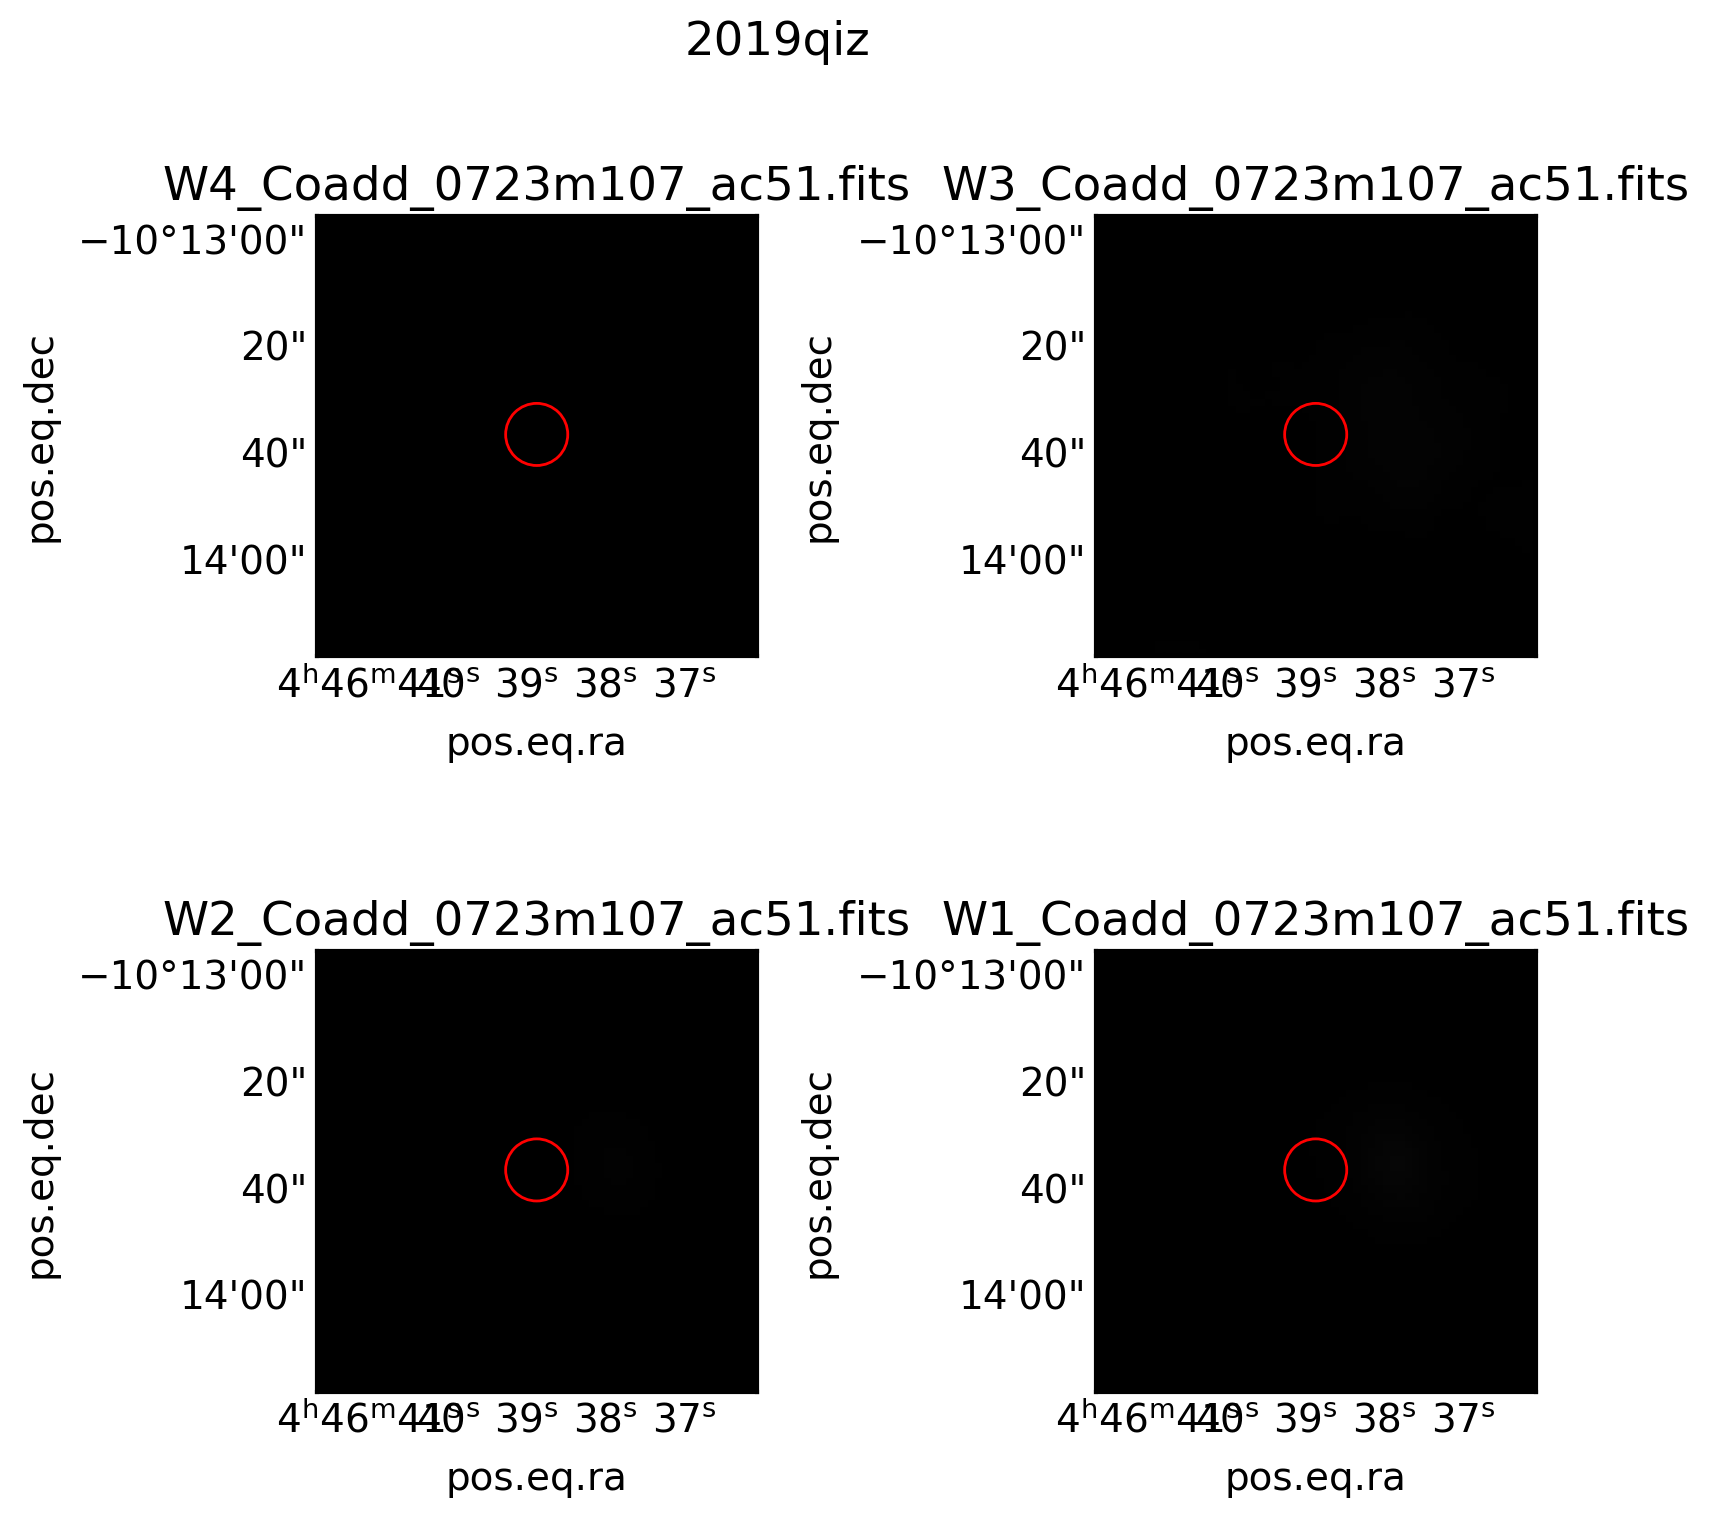

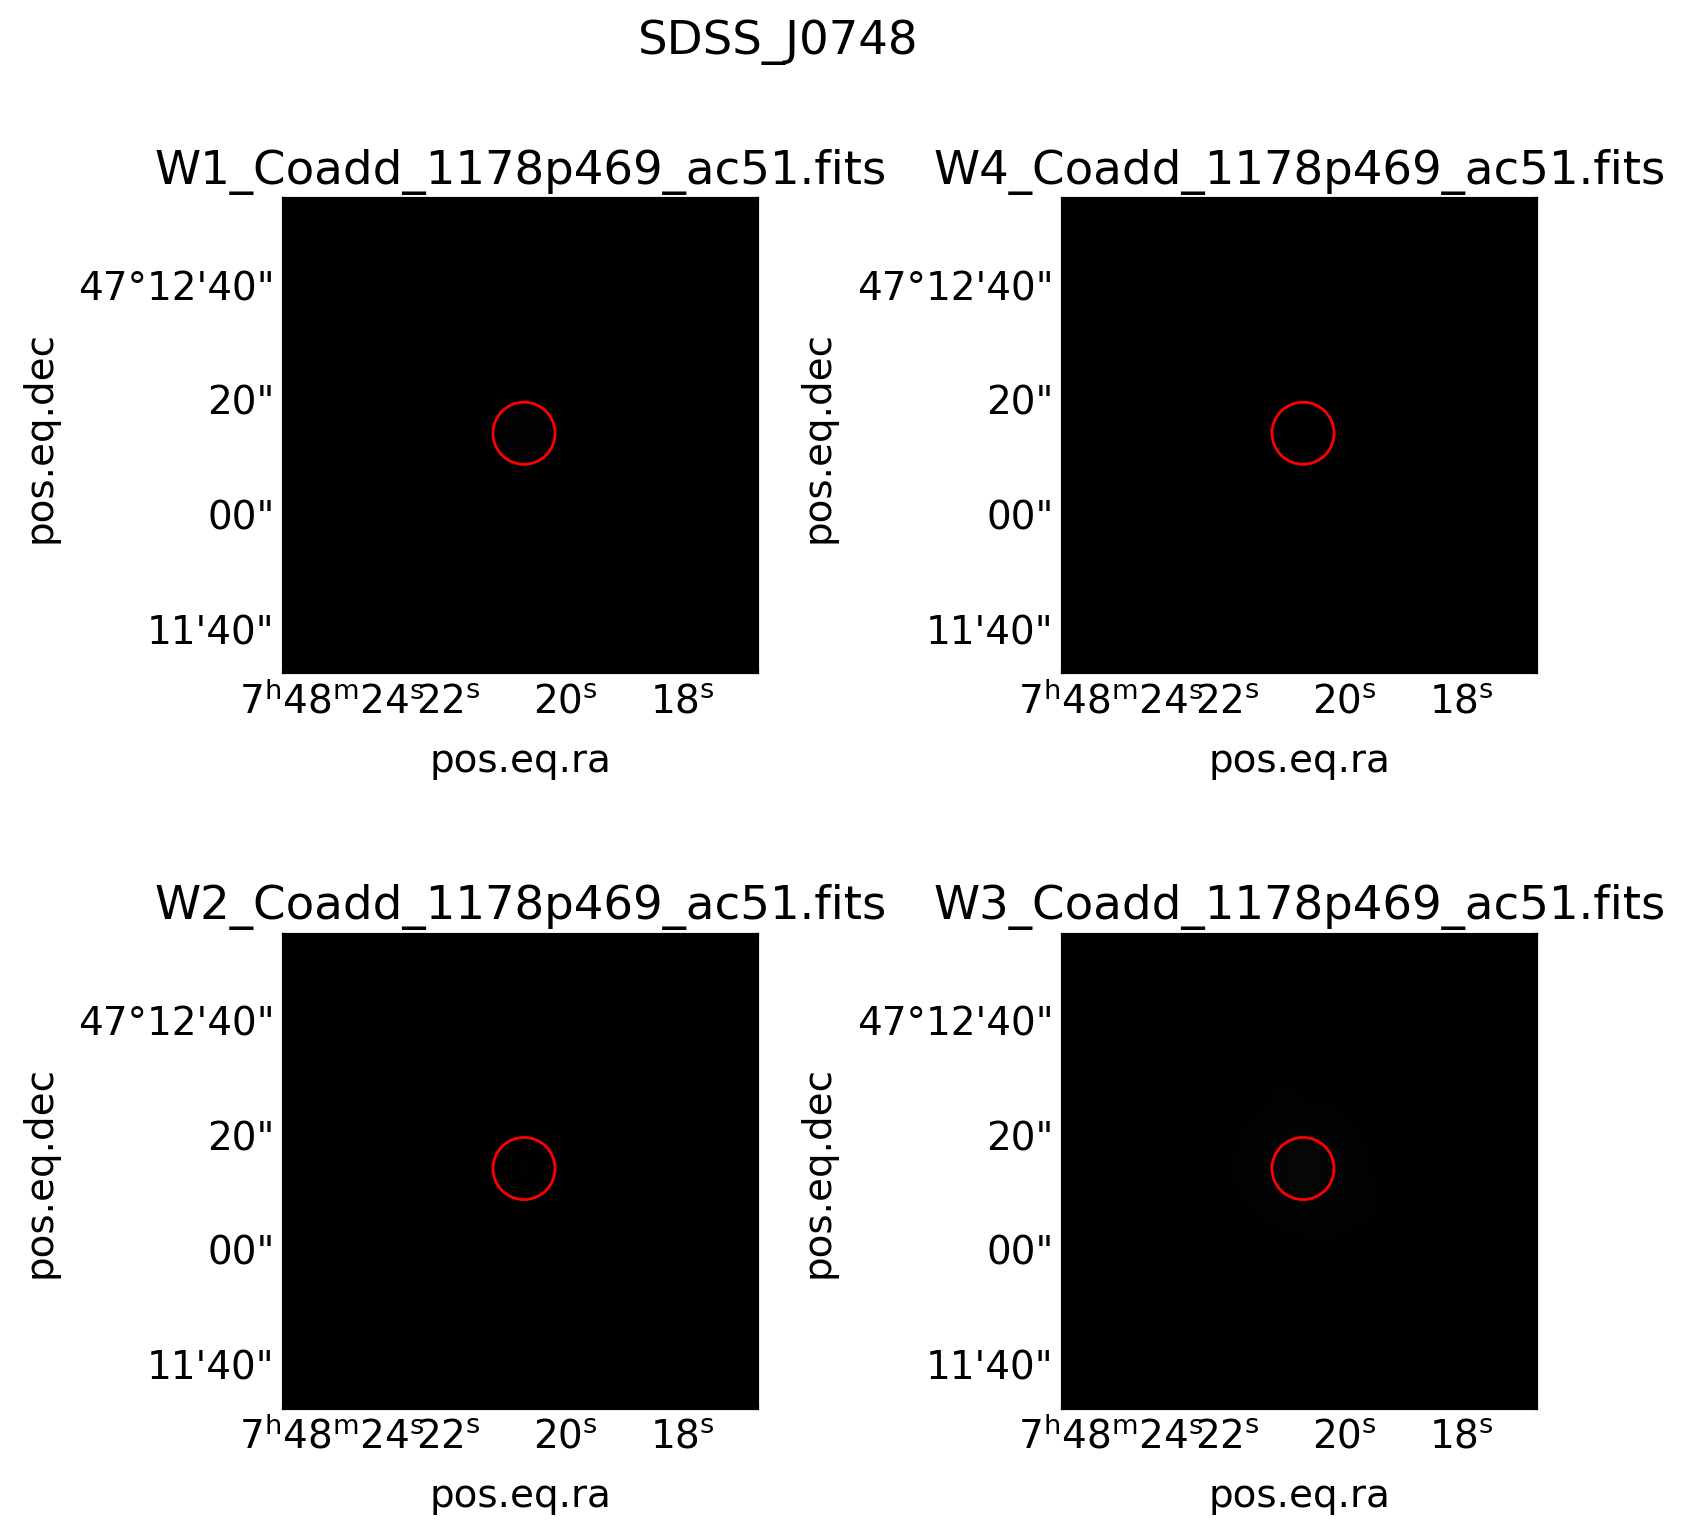

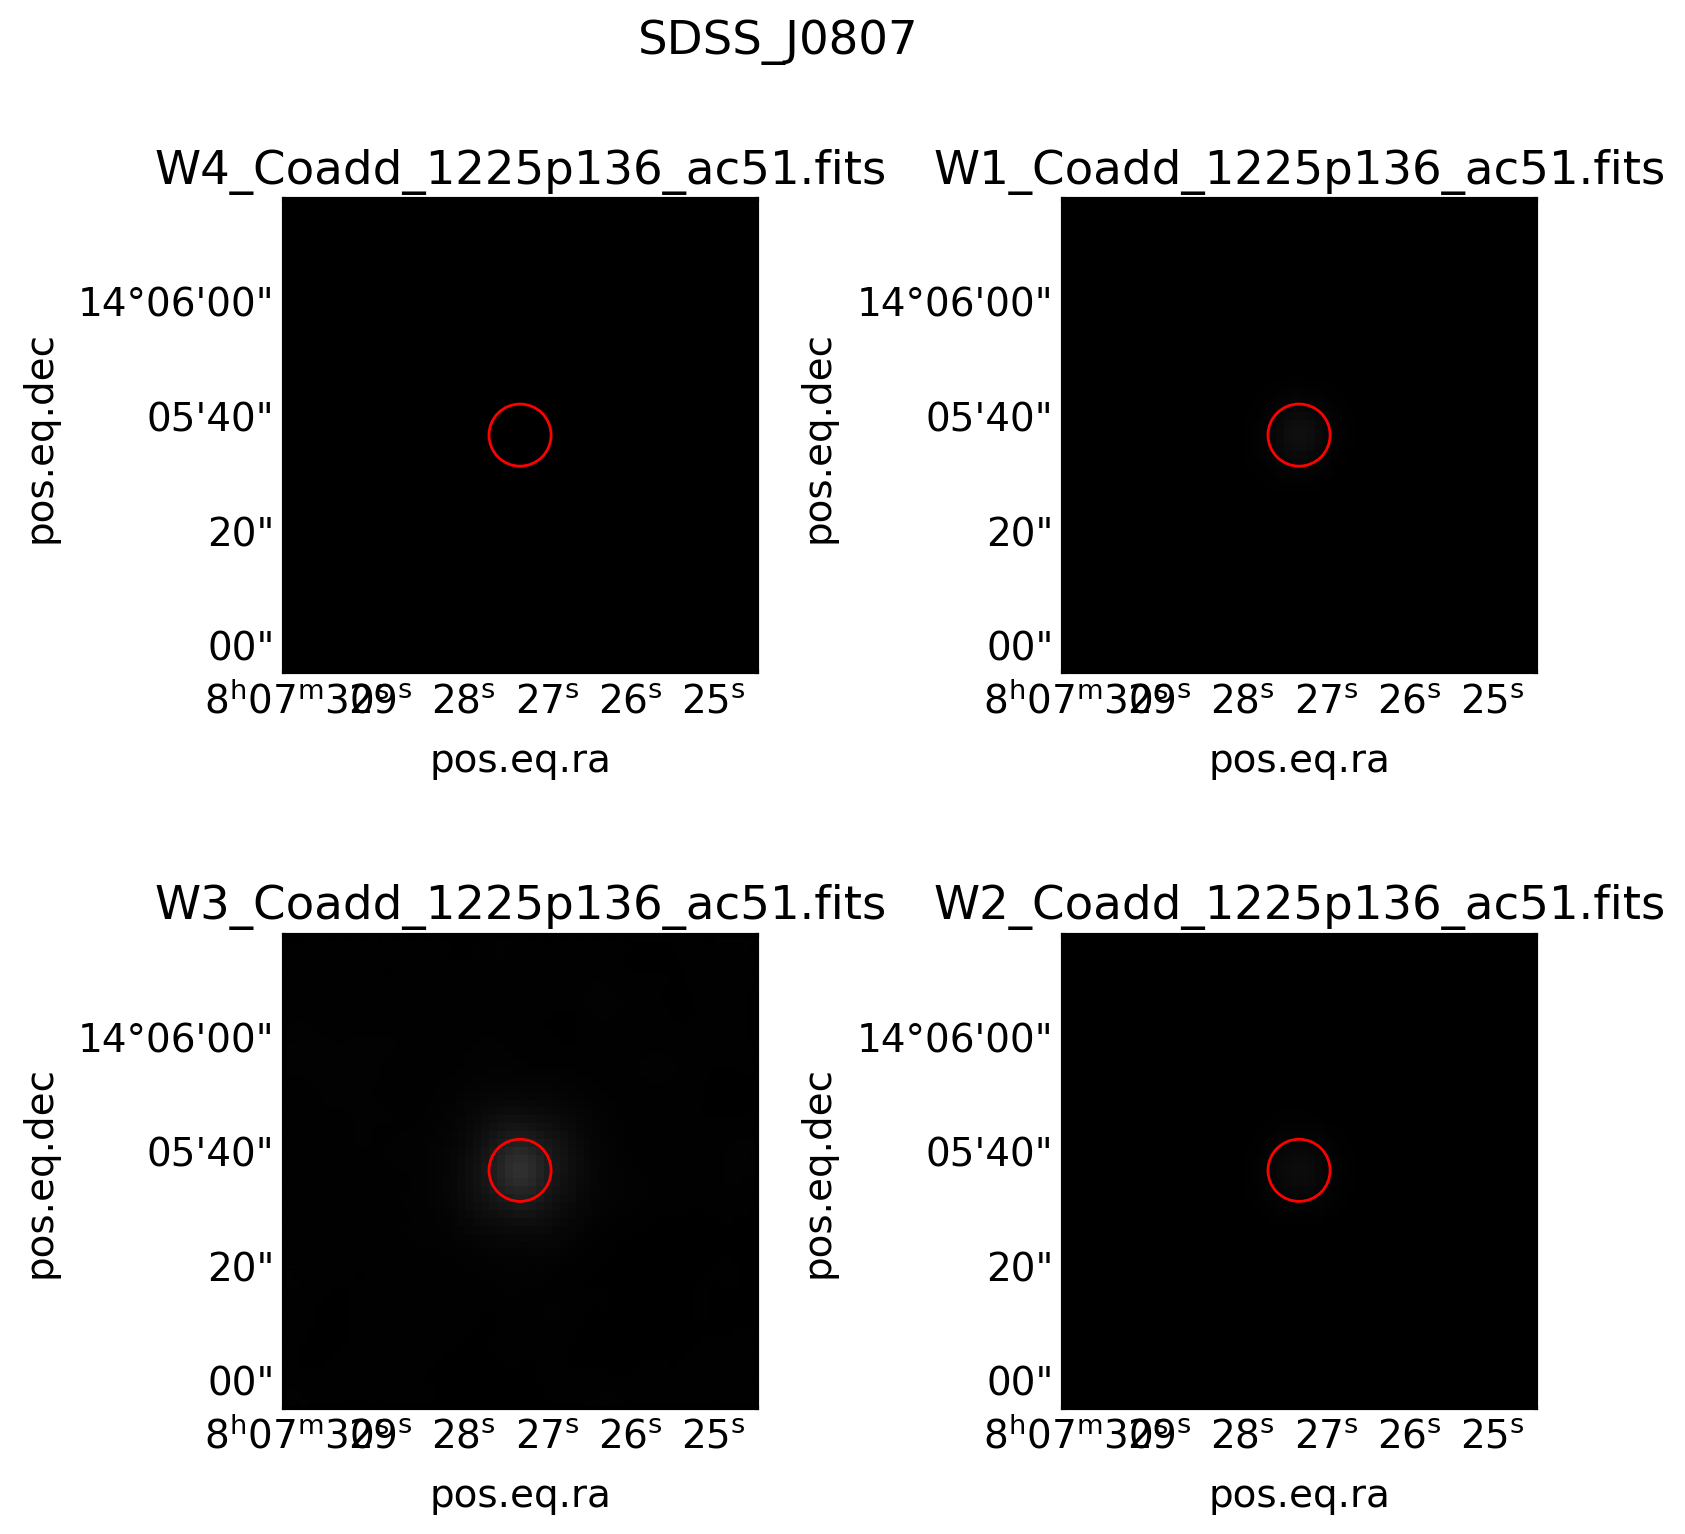

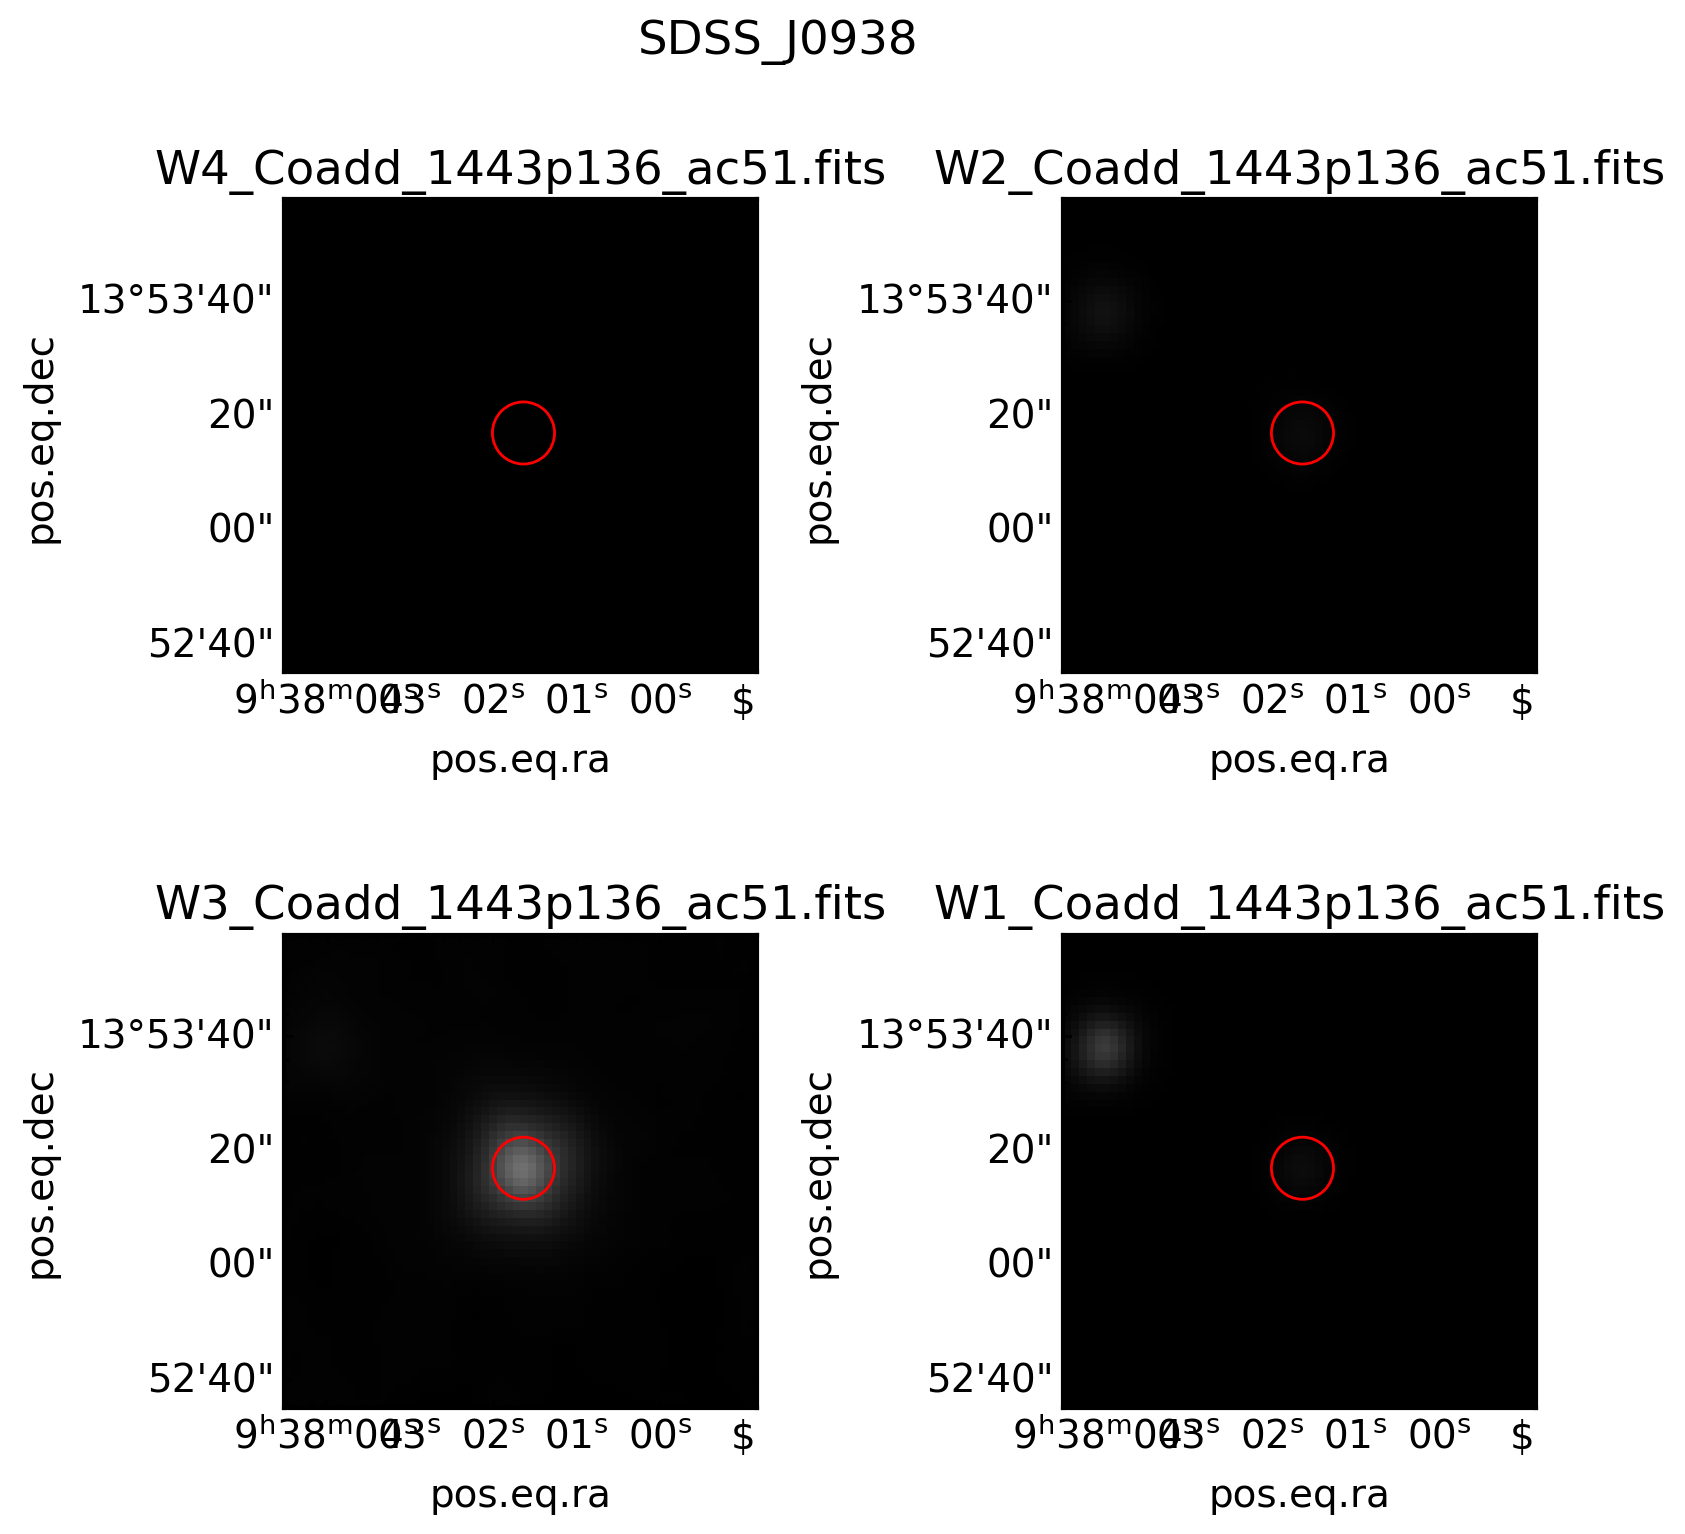

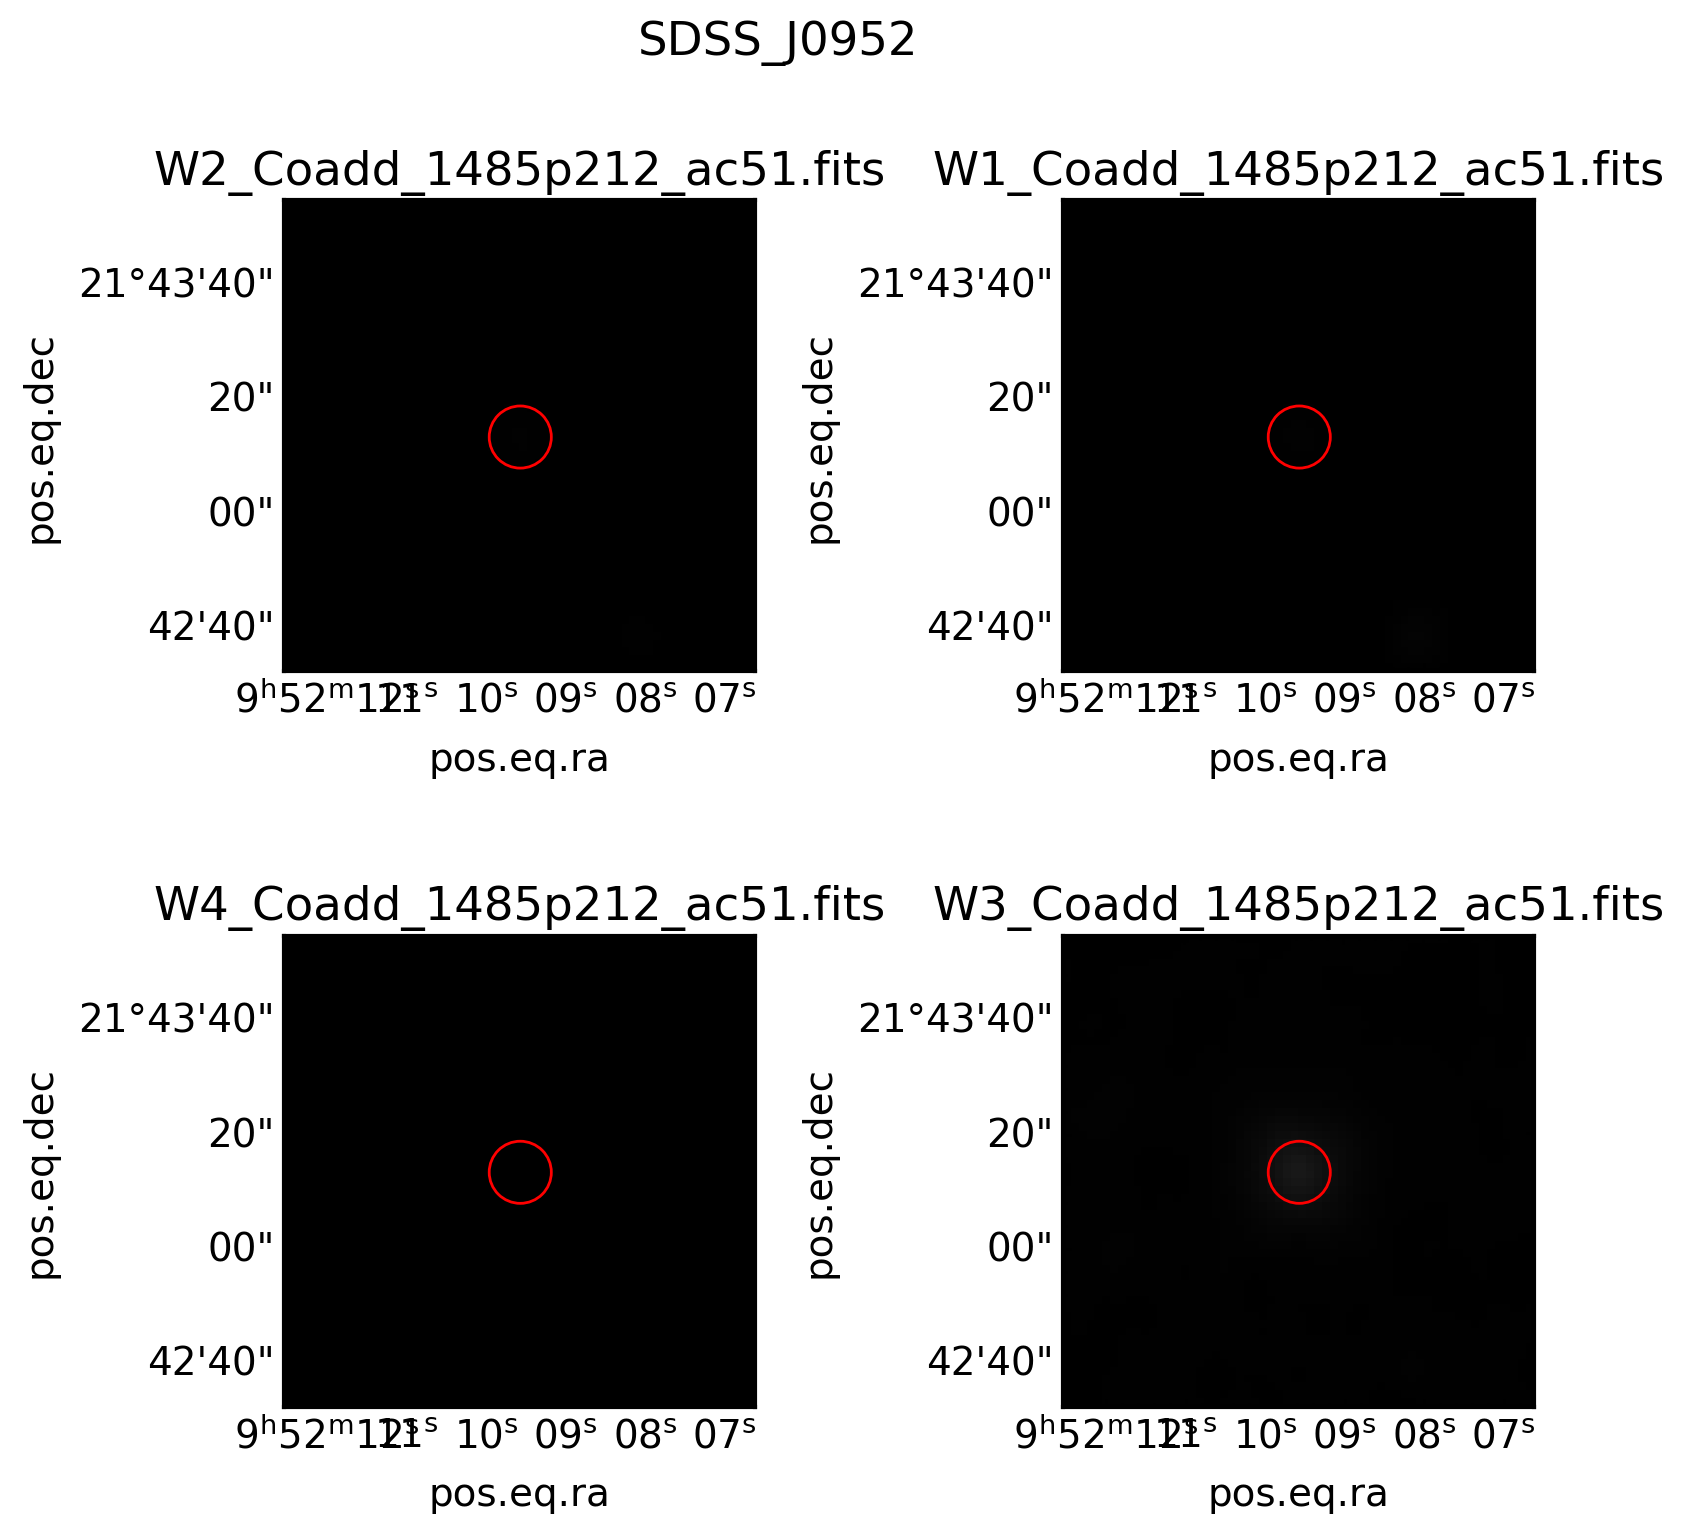

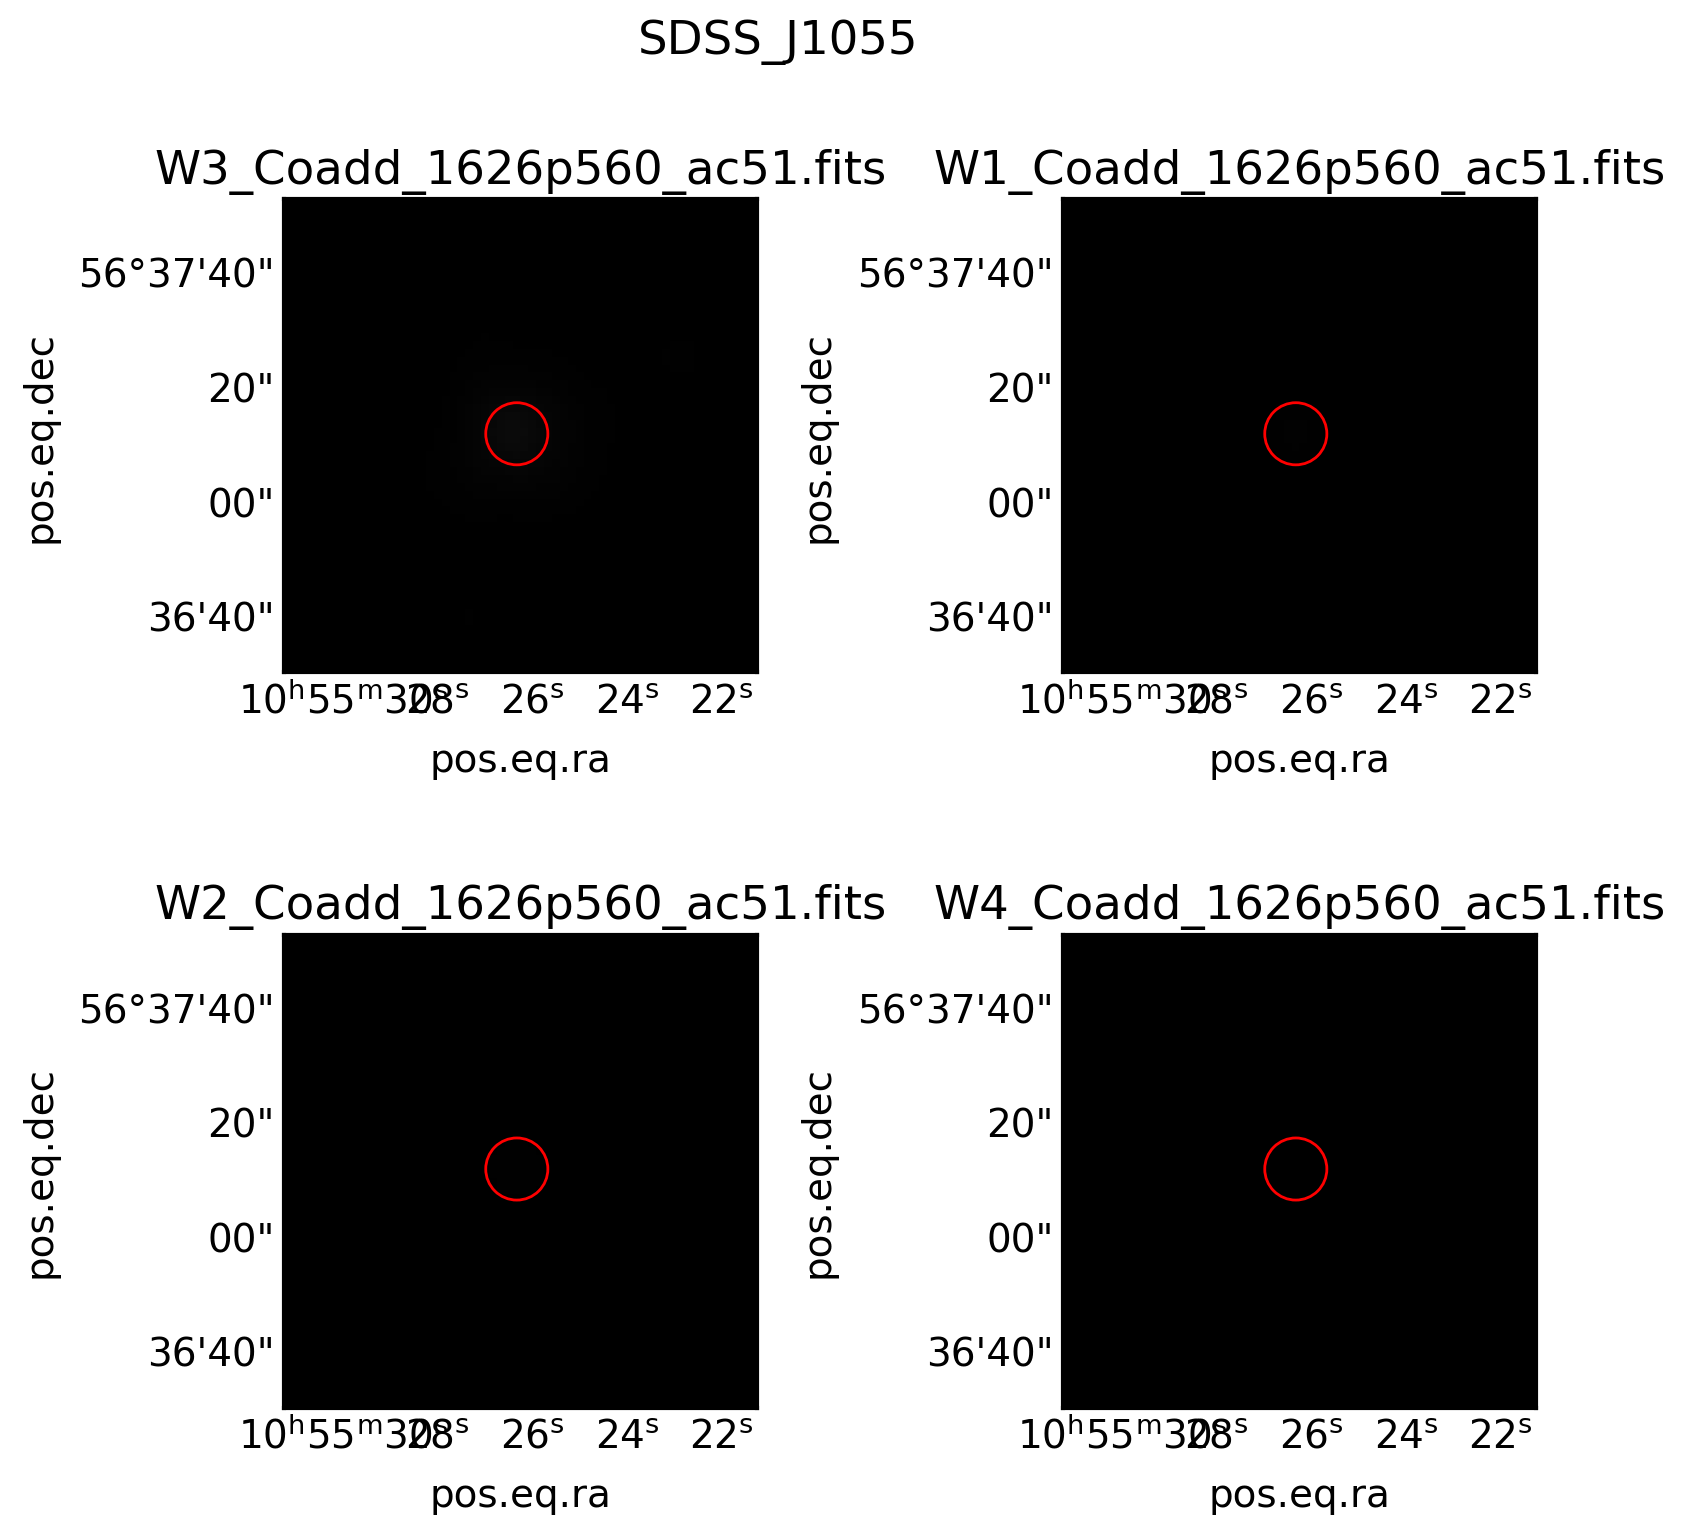

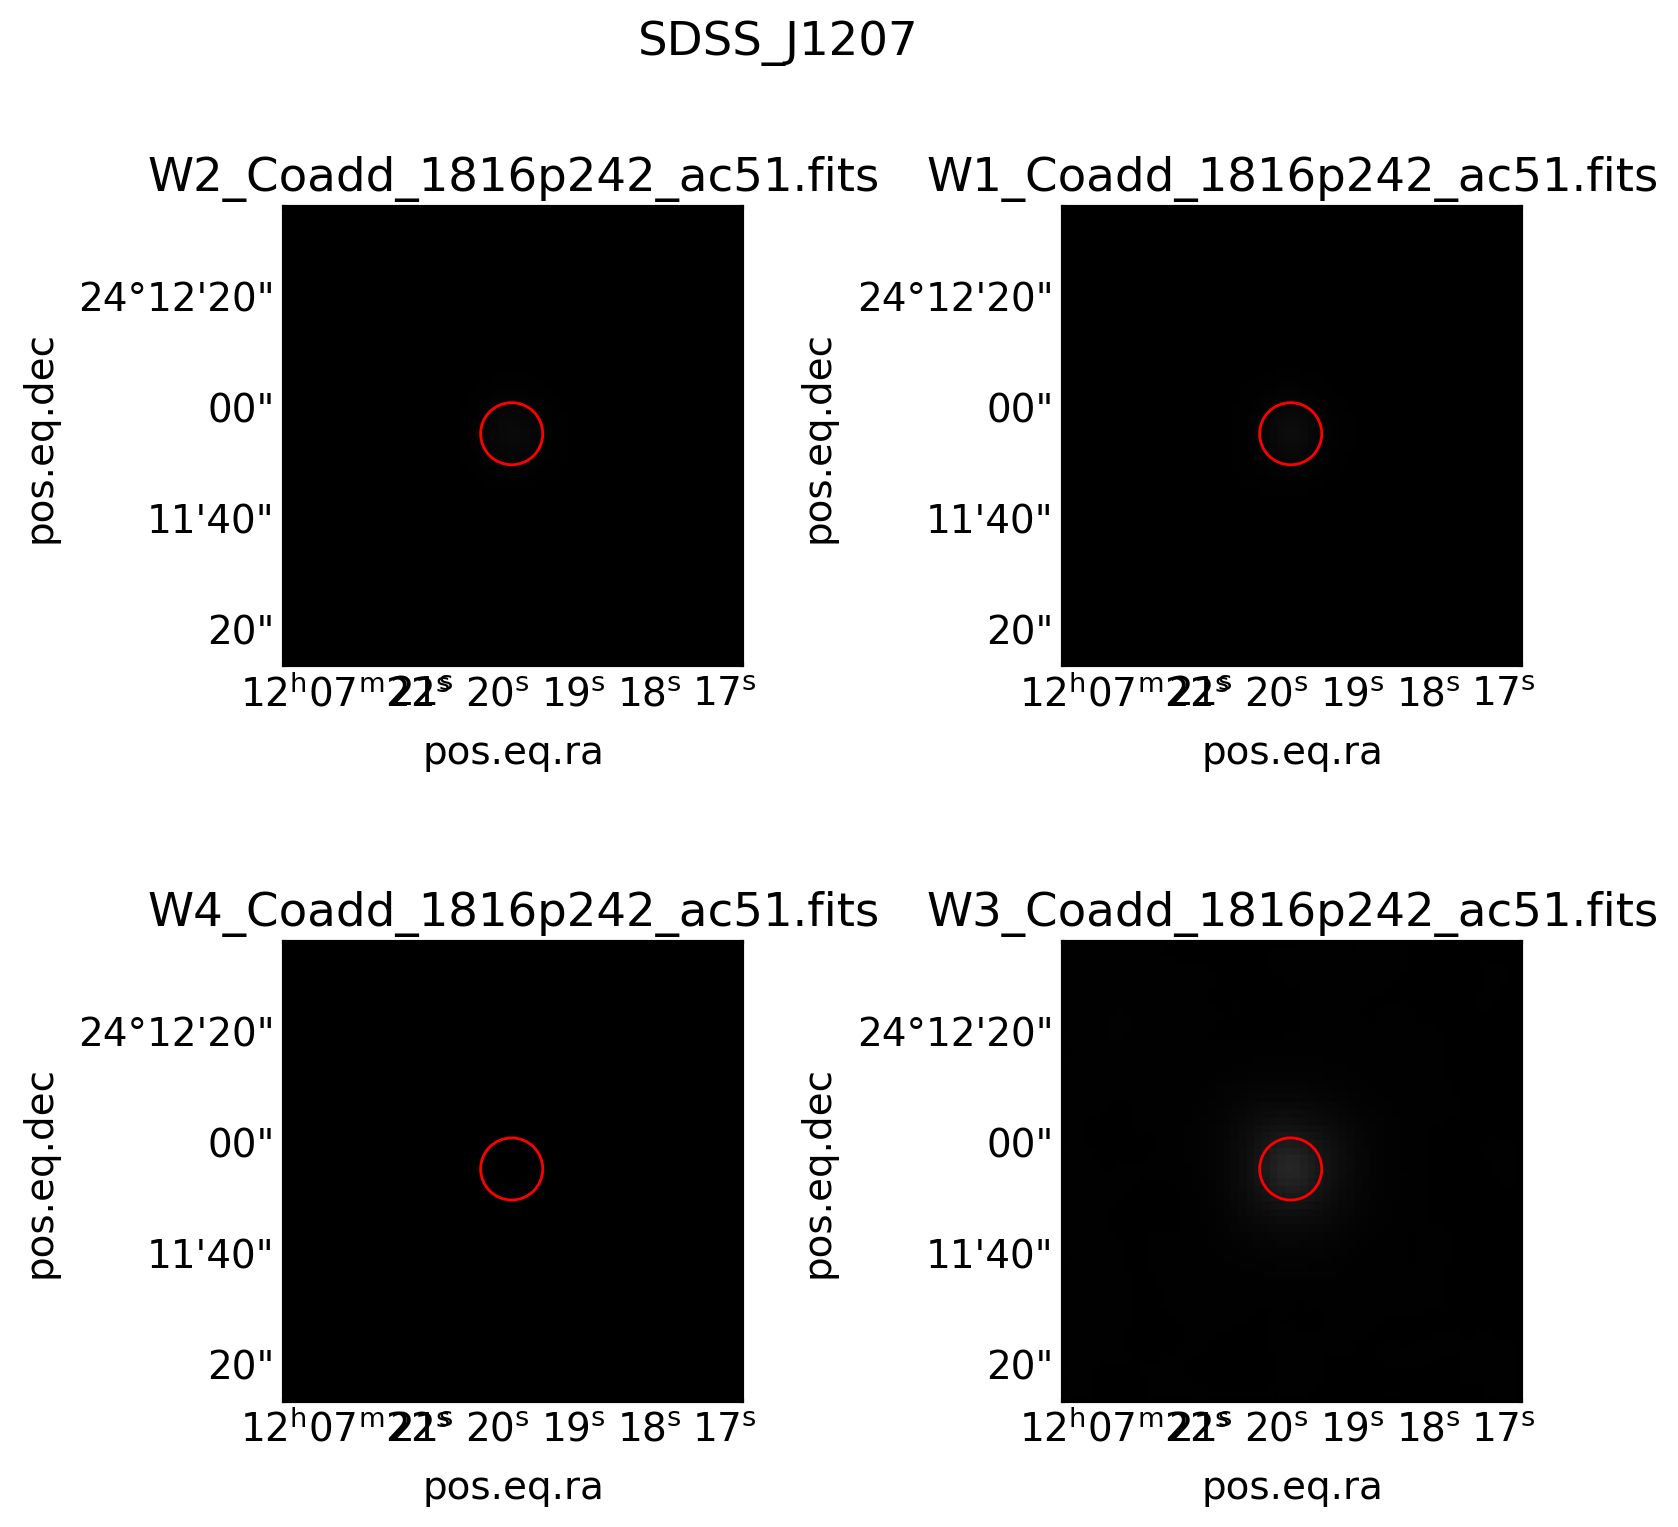

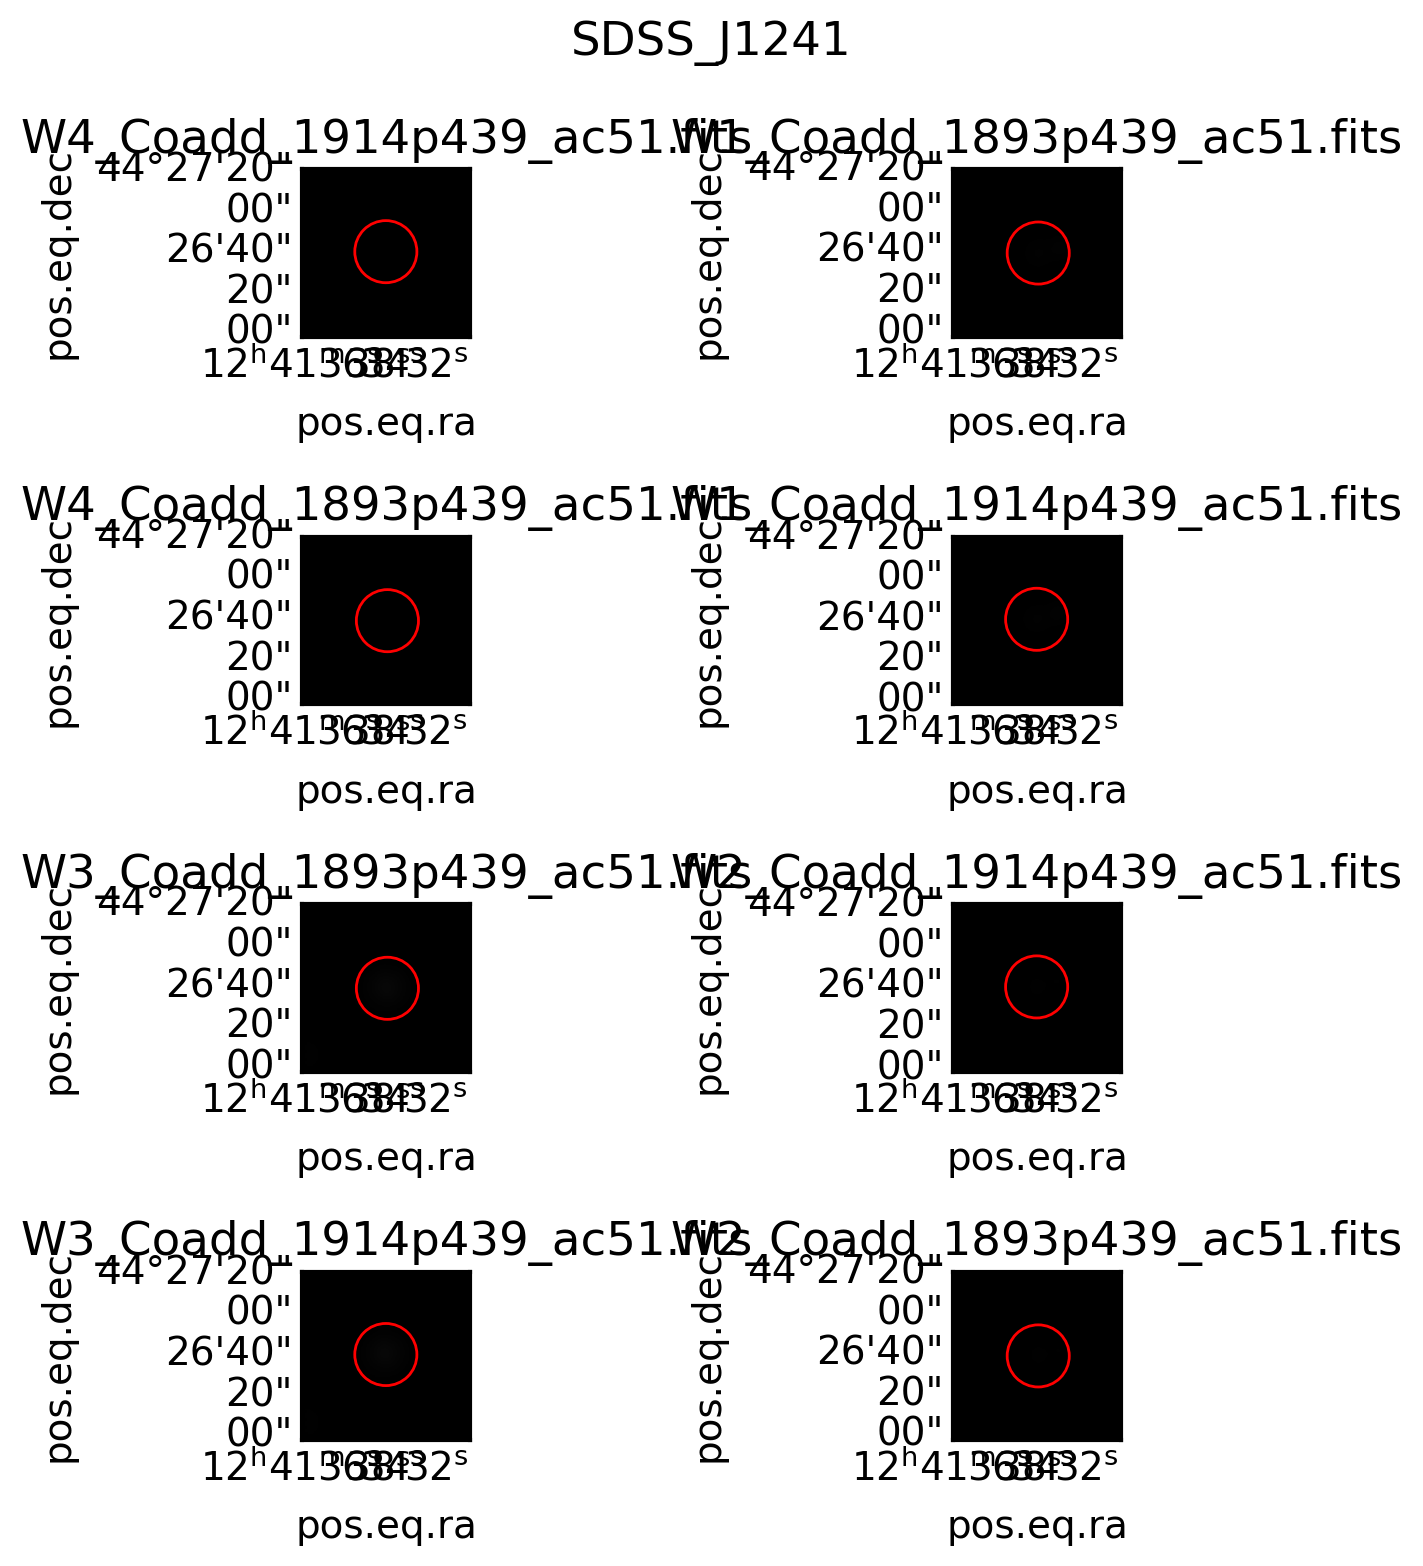

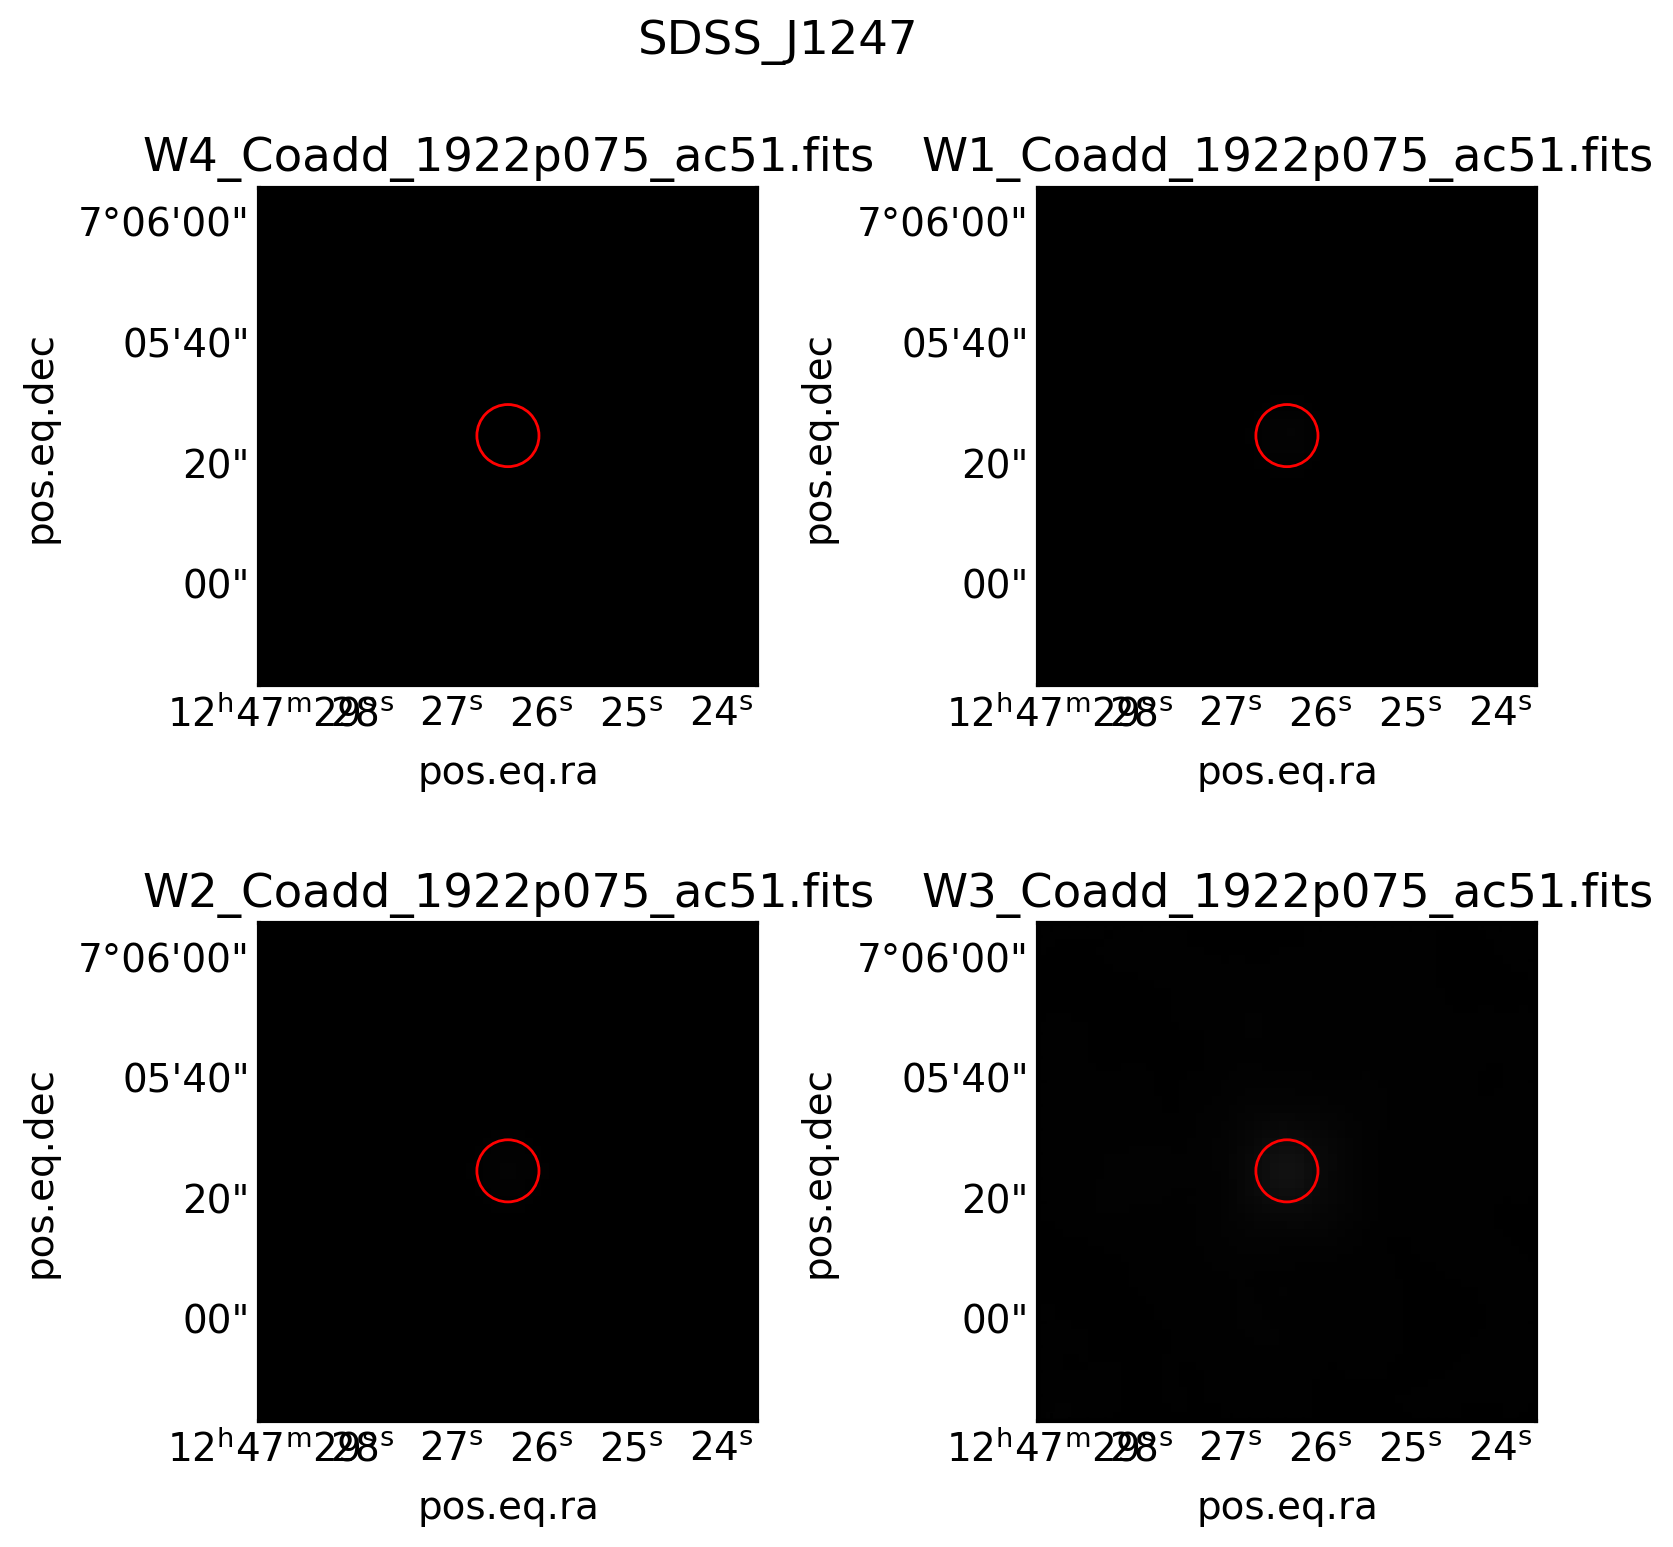

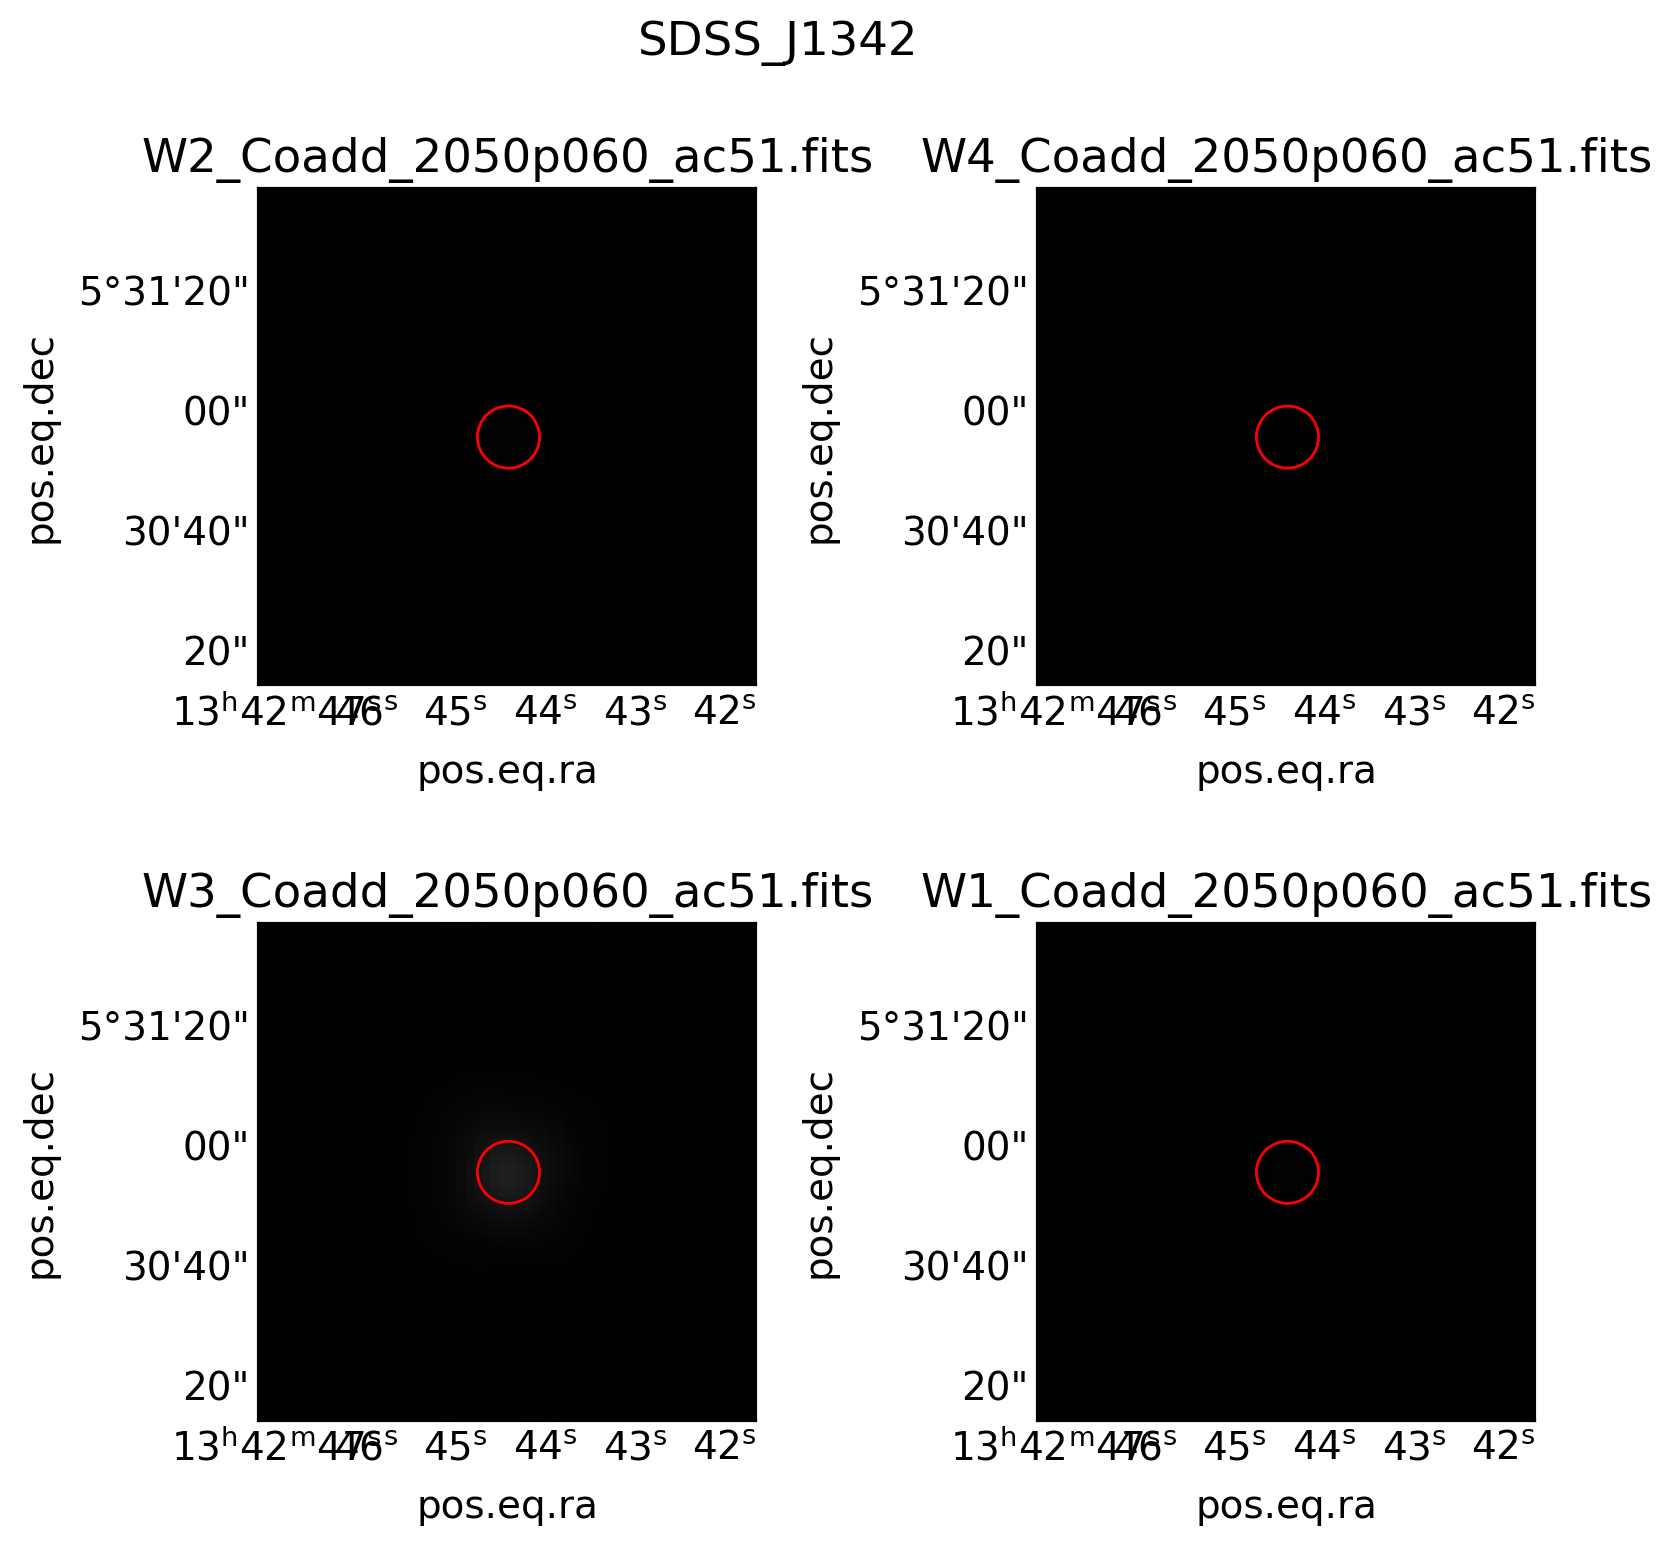

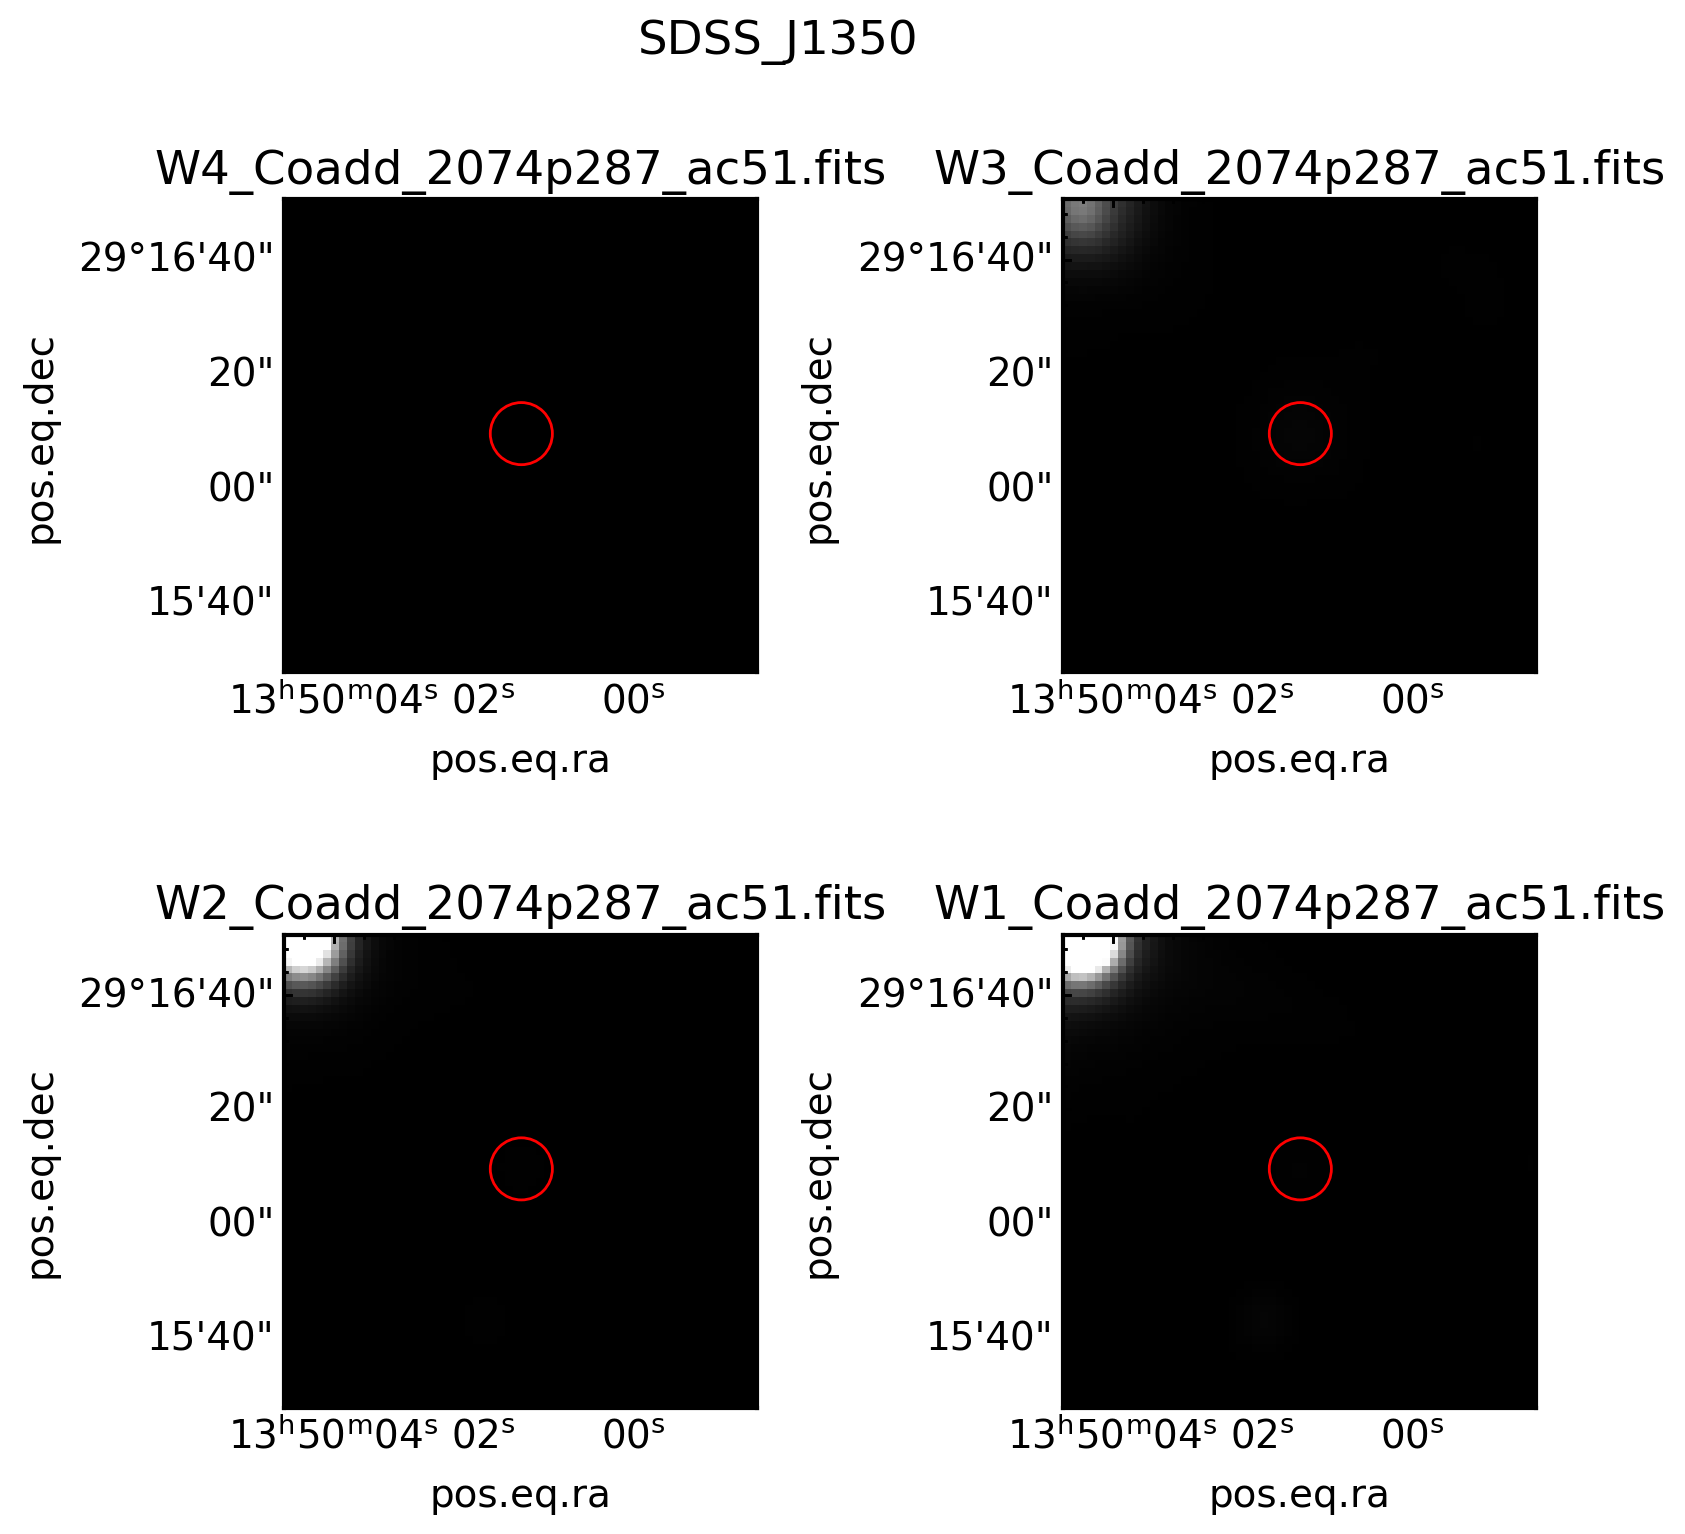

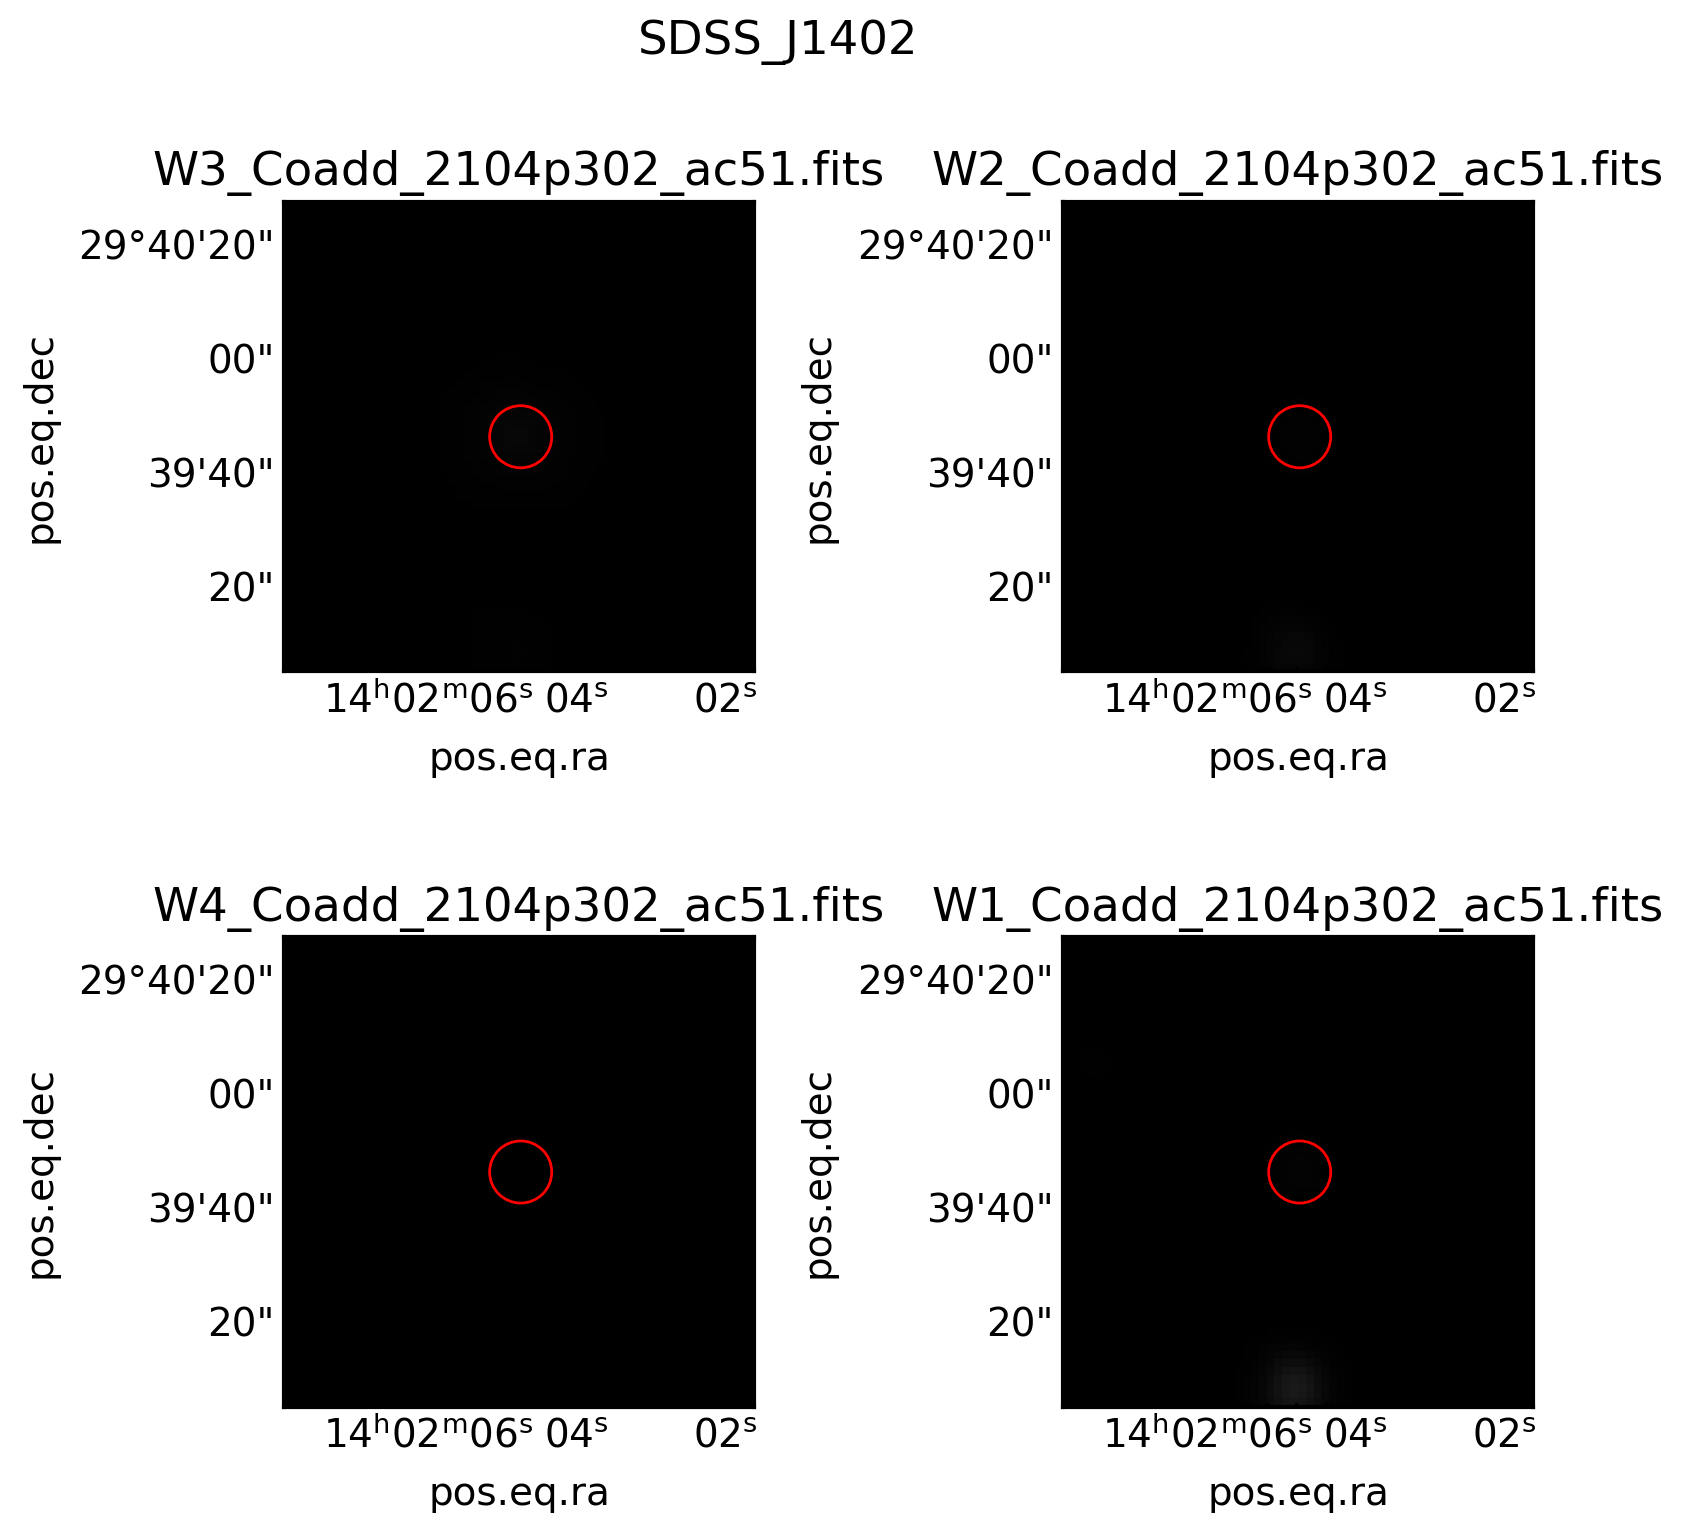

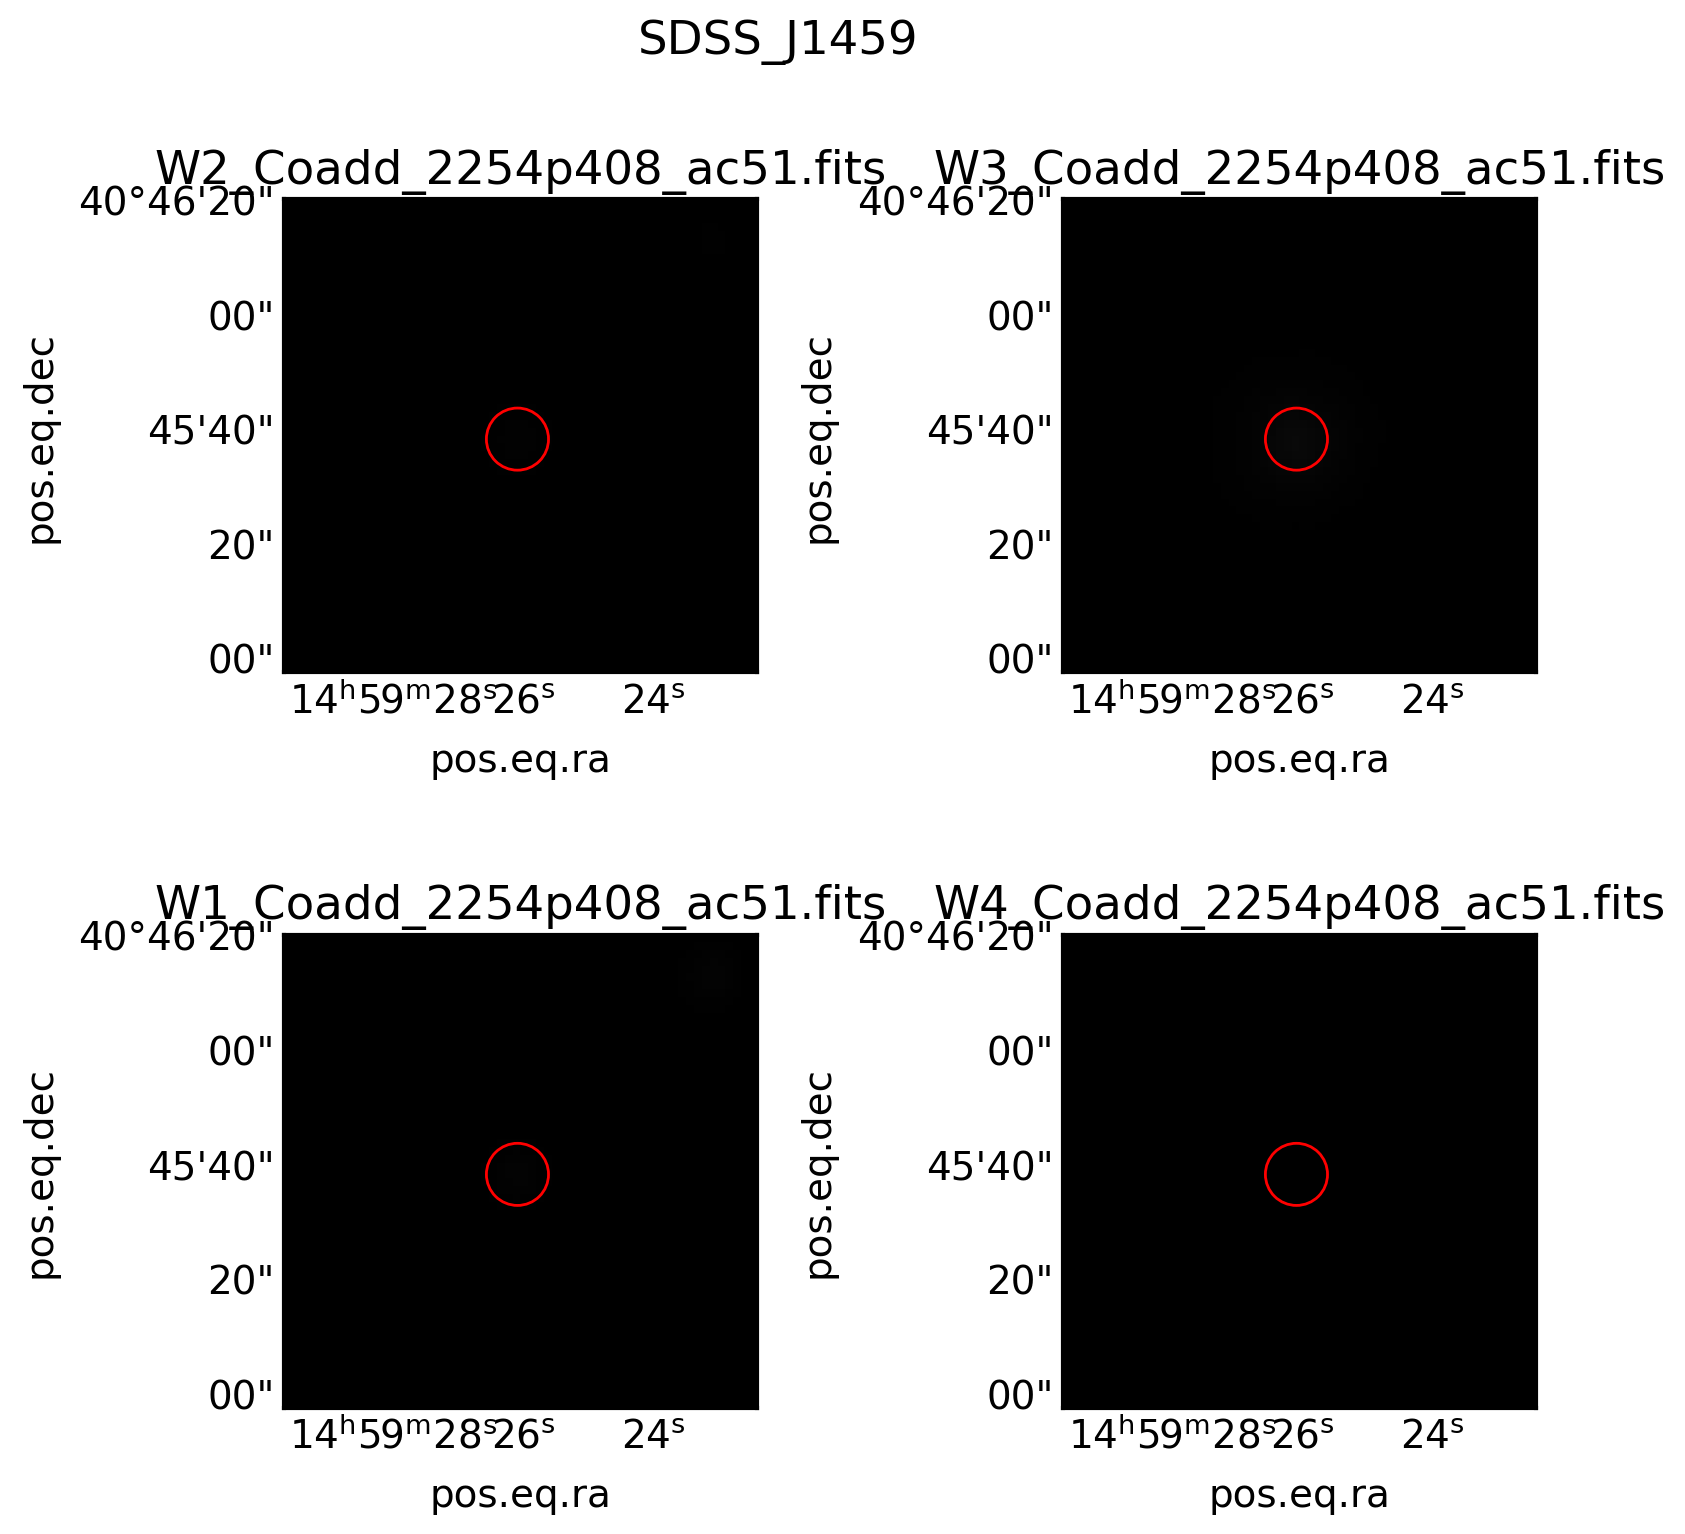

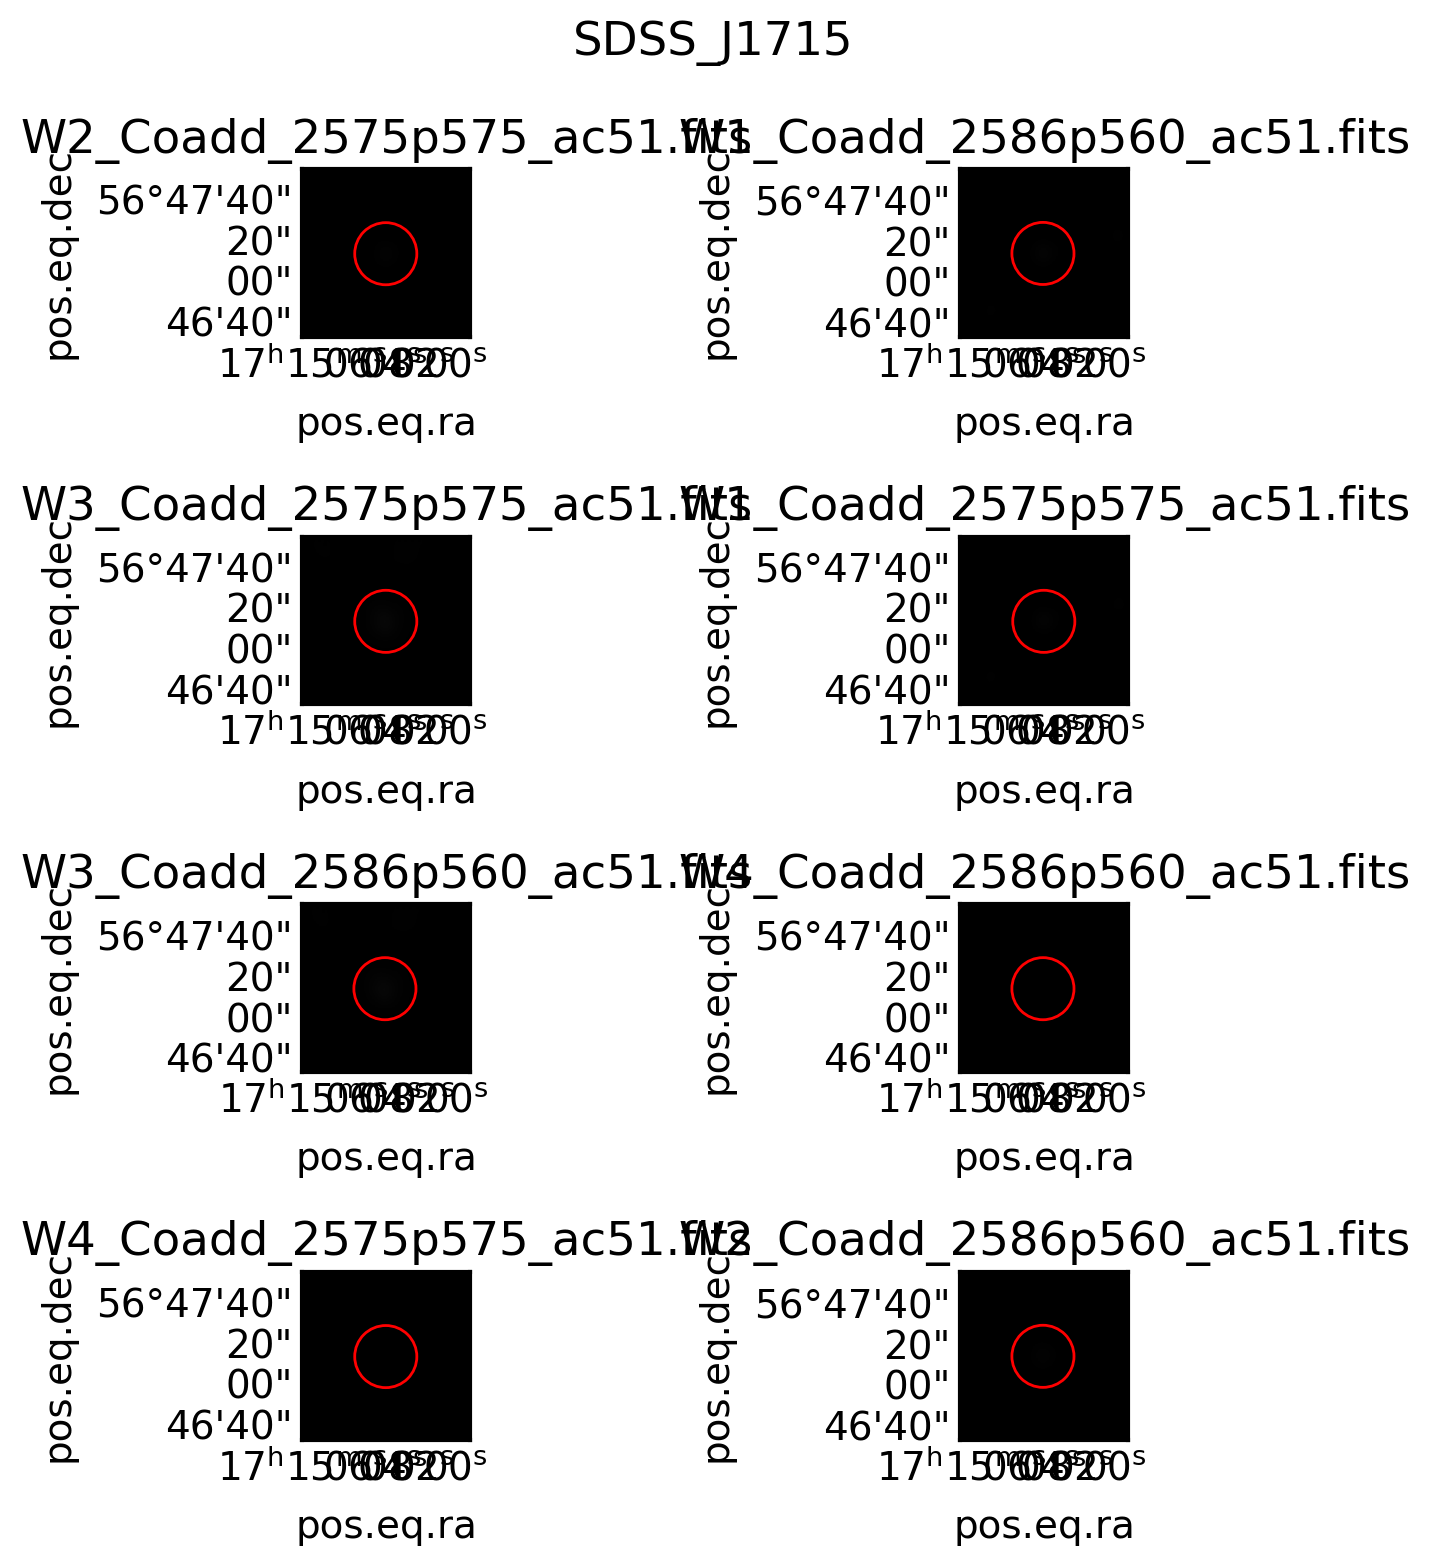

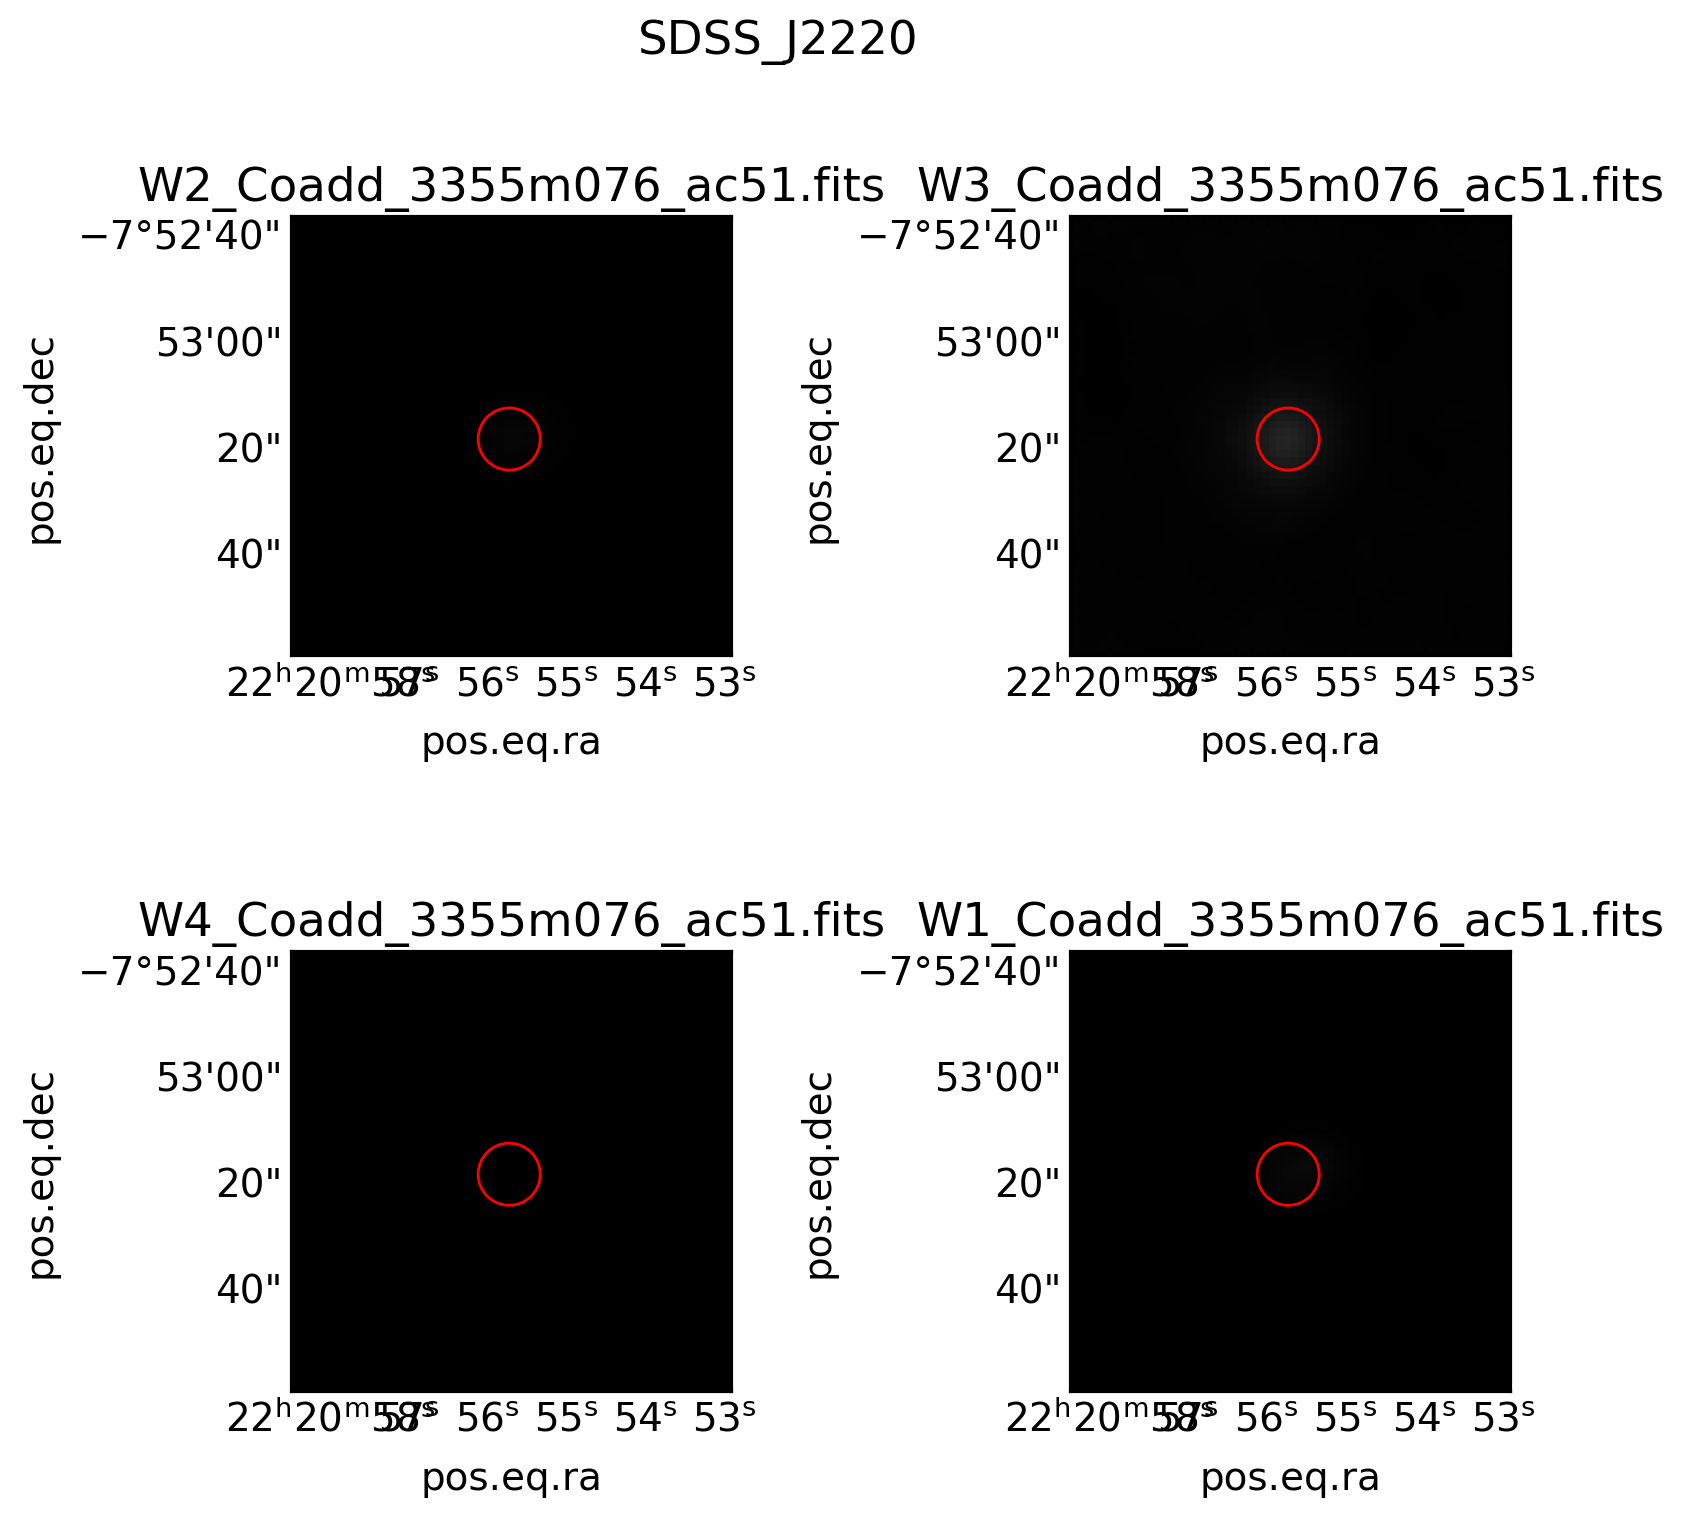

In [67]:
for name in meta['name']:
    fitspath = os.path.join(os.getcwd(), 'wise-fits-data', name)
    show_wise_images(fitspath)